## Section 1:  Setup

In [1]:
# ── Load Data ─────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

import glob
# auto-pick the newest full-week panel (was hardcoded to the deleted 6-day partials)
TRACE_FILE = max(glob.glob('../results/a/panel_*.csv'))
PING_FILE  = max(glob.glob('../results/b/panel_*.csv'))

EXCLUDE_PROBES = {'AS13335.1015491'}  # mislabelled; actually Z-Com, duplicate of probe 7613

trace = pd.read_csv(TRACE_FILE, parse_dates=['ts_utc'])
ping  = pd.read_csv(PING_FILE,  parse_dates=['ts_utc'])

trace_clean = trace[~trace['probe'].isin(EXCLUDE_PROBES)].dropna(subset=['tromboned'])
ping_clean  = ping[~ping['probe'].isin(EXCLUDE_PROBES)].dropna(subset=['rtt_min'])

pk_trace     = trace_clean[trace_clean['cls'] == 'Pakistan'].copy()
pk_ping      = ping_clean[ping_clean['cls']   == 'Pakistan'].copy()
cdn_trace    = trace_clean[trace_clean['cls'] == 'CDN'].copy()
cdn_ping     = ping_clean[ping_clean['cls']   == 'CDN'].copy()
abroad_trace = trace_clean[trace_clean['cls'] == 'Abroad'].copy()
abroad_ping  = ping_clean[ping_clean['cls']   == 'Abroad'].copy()

# NOTE: this is the RAW, uncorrected class split straight from the panel file (the design-time
# 40 PK / 40 CDN / 20 Abroad labels). The Data Cleaning cell below overwrites `cls` with the
# physics-corrected classification (37 PK / 40 CDN / 23 Abroad, targets_corrected.csv) — that
# corrected split is what pk_ping/pk_trace/etc. actually hold for the rest of the notebook.
print(f'Trace rows: {len(trace_clean):,}  |  PK={len(pk_trace):,}  CDN={len(cdn_trace):,}  Abroad={len(abroad_trace):,}')
print(f'Ping rows:  {len(ping_clean):,}   |  PK={len(pk_ping):,}  CDN={len(cdn_ping):,}  Abroad={len(abroad_ping):,}')
print(f'Probes: {sorted(trace_clean["probe"].unique())}')
print(f'PK sites (raw/uncorrected): {pk_trace["target"].nunique()}  CDN sites: {cdn_trace["target"].nunique()}  Abroad sites (raw/uncorrected): {abroad_trace["target"].nunique()}')

Trace rows: 221,105  |  PK=88,433  CDN=88,489  Abroad=44,183
Ping rows:  316,737   |  PK=86,100  CDN=160,694  Abroad=69,943
Probes: ['cybernet.1016036', 'cybernet.1016143', 'cybernet.1016154', 'fasttel.1014872', 'nayatel.60223', 'nayatel.65892', 'nova.1015679', 'orbit.64535', 'ptcl.1016126', 'ptcl.1016393', 'ptcl.7764', 'tes.64078', 'tes.64722', 'transworld.62224', 'zcom.7613']
PK sites (raw/uncorrected): 40  CDN sites: 40  Abroad sites (raw/uncorrected): 20


In [2]:
# ── Data exploration before cleaning ─────────────────────────────────────────

print("=== PING DATA ===")
print(f"Total rows: {len(ping):,}")
print(f"NaN rtt_min: {ping['rtt_min'].isna().sum():,}")
print(f"Loss = 1.0 (100%): {(ping['loss'] == 1.0).sum():,}")
print(f"Loss > 0.5 (>50%): {(ping['loss'] > 0.5).sum():,}")
print(f"\nLoss distribution:")
print(ping['loss'].describe())

print("\n=== TRACE DATA ===")
print(f"Total rows: {len(trace):,}")
print(f"NaN tromboned: {trace['tromboned'].isna().sum():,}")
print(f"NaN hop_count: {trace['hop_count'].isna().sum():,}")
print(f"transit == '?': {(trace['transit'] == '?').sum():,}")
print(f"\nhop_count distribution:")
print(trace['hop_count'].describe())

print("\n=== PER PROBE QUALITY ===")
probe_quality = ping.groupby('probe').agg(
    total_rounds = ('rtt_min', 'count'),
    nan_rtt      = ('rtt_min', lambda x: x.isna().sum()),
    avg_loss     = ('loss', 'mean'),
    median_rtt   = ('rtt_min', 'median')
).round(2)
print(probe_quality.to_string())


=== PING DATA ===
Total rows: 445,749
NaN rtt_min: 126,252
Loss = 1.0 (100%): 126,158
Loss > 0.5 (>50%): 127,668

Loss distribution:
count    445655.000000
mean          0.288339
std           0.450100
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max           1.000000
Name: loss, dtype: float64

=== TRACE DATA ===
Total rows: 222,944
NaN tromboned: 0
NaN hop_count: 33,520
transit == '?': 100,643

hop_count distribution:
count    189424.000000
mean         66.823623
std         103.192579
min           0.000000
25%           9.000000
50%          11.000000
75%          18.000000
max         255.000000
Name: hop_count, dtype: float64

=== PER PROBE QUALITY ===
                  total_rounds  nan_rtt  avg_loss  median_rtt
probe                                                        
AS13335.1015491           2760      912      0.25       104.3
cybernet.1016036         25718     7882      0.24       117.7
cybernet.1016143         25749     78

In [3]:
# ── Data cleaning ─────────────────────────────────────────────────────────────

# exclude ptcl.7764 — 90% packet loss, data unreliable
# exclude AS13335.1015491 — mislabelled probe, actually Z-Com (AS152605); a duplicate vantage of
# probe 7613 (Z-Com, Lahore), so keeping both would double-count Z-Com relative to other ISPs
EXCLUDE_PROBES = {'AS13335.1015491', 'ptcl.7764'}

ping_clean  = ping[~ping['probe'].isin(EXCLUDE_PROBES)].copy()
trace_clean = trace[~trace['probe'].isin(EXCLUDE_PROBES)].copy()

# drop ping rows where rtt_min is NaN (100% loss — no RTT to analyse)
ping_clean = ping_clean.dropna(subset=['rtt_min'])

# apply the physics-corrected site classification (targets_corrected.csv, from geo.py correct):
# 3 sites labelled Pakistan at scheduling time are actually far abroad (nearest probe RTT
# 77-206 ms) and were re-classed to Abroad — see METHODOLOGY.md §3b. This makes `cls` here
# consistent with cls_corrected, already used by cdn.csv / ratio_corrected.csv.
cls_corrected = pd.read_csv('targets_corrected.csv').set_index('target')['cls_corrected']
ping_clean['cls']  = ping_clean['target'].map(cls_corrected)
trace_clean['cls'] = trace_clean['target'].map(cls_corrected)

# drop hop_count == 255 (timeout) for hop analysis only
trace_hops = trace_clean[trace_clean['hop_count'] != 255].copy()

# subsets by hosting class
pk_ping     = ping_clean[ping_clean['cls'] == 'Pakistan'].copy()
cdn_ping    = ping_clean[ping_clean['cls'] == 'CDN'].copy()
abroad_ping = ping_clean[ping_clean['cls'] == 'Abroad'].copy()

pk_trace     = trace_clean[trace_clean['cls'] == 'Pakistan'].copy()
cdn_trace    = trace_clean[trace_clean['cls'] == 'CDN'].copy()
abroad_trace = trace_clean[trace_clean['cls'] == 'Abroad'].copy()

print(f"Ping after cleaning:  {len(ping_clean):,} rows, {ping_clean['probe'].nunique()} probes")
print(f"Trace after cleaning: {len(trace_clean):,} rows")
print(f"\nPing by class:  PK={len(pk_ping):,}  CDN={len(cdn_ping):,}  Abroad={len(abroad_ping):,}")
print(f"Trace by class: PK={len(pk_trace):,}  CDN={len(cdn_trace):,}  Abroad={len(abroad_trace):,}")
print(f"\nProbes retained: {sorted(ping_clean['probe'].unique())}")

Ping after cleaning:  313,276 rows, 14 probes
Trace after cleaning: 204,384 rows

Ping by class:  PK=72,617  CDN=158,940  Abroad=81,719
Trace by class: PK=75,600  CDN=81,802  Abroad=46,982

Probes retained: ['cybernet.1016036', 'cybernet.1016143', 'cybernet.1016154', 'fasttel.1014872', 'nayatel.60223', 'nayatel.65892', 'nova.1015679', 'orbit.64535', 'ptcl.1016126', 'ptcl.1016393', 'tes.64078', 'tes.64722', 'transworld.62224', 'zcom.7613']


In [4]:
# ── Mapping ─────────────────────────────────────────────────────────────

PROBE_LABELS = {
    'cybernet.1016036': 'Cybernet (Haripur)',
    'cybernet.1016143': 'Cybernet (Karachi)',
    'cybernet.1016154': 'Cybernet (Karachi)',
    'fasttel.1014872':  'Fasttel (Islamabad)',
    'nayatel.60223':    'Nayatel (Islamabad)',
    'nayatel.65892':    'Nayatel (Islamabad)',
    'nova.1015679':     'Nova (Lahore)',
    'orbit.64535':      'Orbit (Faisalabad)',
    'ptcl.1016126':     'PTCL (Karachi)',
    'ptcl.1016393':     'PTCL (Mianwali)',
    'tes.64078':        'TES (Rawalpindi)',
    'tes.64722':        'TES (Karachi)',
    'transworld.62224': 'Transworld (Lahore)',
    'zcom.7613':        'Zcom (Lahore)',
}

PROBE_ISP = {
    'cybernet.1016036': 'Cybernet',
    'cybernet.1016143': 'Cybernet',
    'cybernet.1016154': 'Cybernet',
    'fasttel.1014872':  'Fasttel',
    'nayatel.60223':    'Nayatel',
    'nayatel.65892':    'Nayatel',
    'nova.1015679':     'Nova',
    'orbit.64535':      'Orbit',
    'ptcl.1016126':     'PTCL',
    'ptcl.1016393':     'PTCL',
    'tes.64078':        'TES',
    'tes.64722':        'TES',
    'transworld.62224': 'Transworld',
    'zcom.7613':        'Zcom',
}



for df in [ping_clean, trace_clean, pk_ping, pk_trace,
           cdn_ping, cdn_trace, abroad_ping, abroad_trace]:
    df['probe_label'] = df['probe'].map(PROBE_LABELS)
    df['probe_isp']   = df['probe'].map(PROBE_ISP)

print(ping_clean[['probe','probe_label','probe_isp']].drop_duplicates().to_string())

                 probe          probe_label   probe_isp
37    cybernet.1016036   Cybernet (Haripur)    Cybernet
373   cybernet.1016143   Cybernet (Karachi)    Cybernet
709   cybernet.1016154   Cybernet (Karachi)    Cybernet
723    fasttel.1014872  Fasttel (Islamabad)     Fasttel
1041     nayatel.60223  Nayatel (Islamabad)     Nayatel
1373     nayatel.65892  Nayatel (Islamabad)     Nayatel
1710      nova.1015679        Nova (Lahore)        Nova
2045       orbit.64535   Orbit (Faisalabad)       Orbit
2370      ptcl.1016126       PTCL (Karachi)        PTCL
2706      ptcl.1016393      PTCL (Mianwali)        PTCL
3112         tes.64078     TES (Rawalpindi)         TES
3448         tes.64722        TES (Karachi)         TES
3783  transworld.62224  Transworld (Lahore)  Transworld
4119         zcom.7613        Zcom (Lahore)        Zcom


In [5]:
# check hop count availability per probe
hop_check = trace_clean.groupby('probe_label').agg(
    total_rounds = ('hop_count', 'count'),
    nan_hops     = ('hop_count', lambda x: x.isna().sum()),
    median_hops  = ('hop_count', 'median')
).round(1)
print(hop_check.to_string())

                     total_rounds  nan_hops  median_hops
probe_label                                             
Cybernet (Haripur)          16800         0         11.0
Cybernet (Karachi)          17497         0         16.0
Fasttel (Islamabad)         15923         0         12.0
Nayatel (Islamabad)         33409         0        255.0
Nova (Lahore)               16800         0         11.0
Orbit (Faisalabad)          16247         0         13.0
PTCL (Karachi)              16800         0         10.0
PTCL (Mianwali)              3856         0         10.0
TES (Karachi)               16800         0         11.0
TES (Rawalpindi)            16797         0         11.0
Transworld (Lahore)             0     16799          NaN
Zcom (Lahore)               16656         0         10.0


**Probe Quality**

**Transworld (Lahore)** is fully ICMP-filtered — no intermediate hops respond in any traceroute round. Its ping RTT is valid and used for latency analysis but it is excluded from all hop-count and path-based analyses.

**Nayatel (Islamabad)** shows a median hop count of 255 across most traceroute rounds, meaning destinations frequently did not reply to its traces. Its ping RTT remains valid and is used for RTT analysis. Hop count results for Nayatel should be interpreted with caution.

**Cybernet (Haripur)** has a placeholder coordinate (30.0, 70.0) declared to RIPE Atlas. It is excluded from all distance-based and ratio analyses but retained for trombone classification since the tromboned verdict is derived from RTT physics and does not require accurate coordinates.

**PTCL (Mianwali)** disconnected on July 17 but contributed 3,678 rounds of valid data covering July 11-17 and is retained in all analyses with a note about the shorter window.

Summary of Cleaning: 
- excluded probe AS13335.1015491 — not actually Cloudflare, it's mislabelled; its real ASN is 152605 (Z-Com). Still excluded, but because it's a **duplicate** Z-Com vantage (probe 7613 already covers Z-Com/Lahore), not because it's a foreign ISP.
- excluded ptcl.7764 because of 90% packet loss, data unreliable
- dropped ping rows where rtt_min is NaN as these are 100% loss rounds with no RTT to measure
- **applied the corrected site classification** (`targets_corrected.csv`): 3 sites tagged Pakistan at scheduling time are actually far abroad (nearest probe 77-206 ms) and are re-classed to Abroad, giving **37 PK / 40 CDN / 23 Abroad** instead of the original 40/40/20 design split — see `METHODOLOGY.md §3b`
- kept trace rows even if transit is '?' but tromboned True/False is still valid
- created trace_hops separately dropping hop_count 255 (timeouts) which is only for hop count analysis

## Section 2: Overview figures

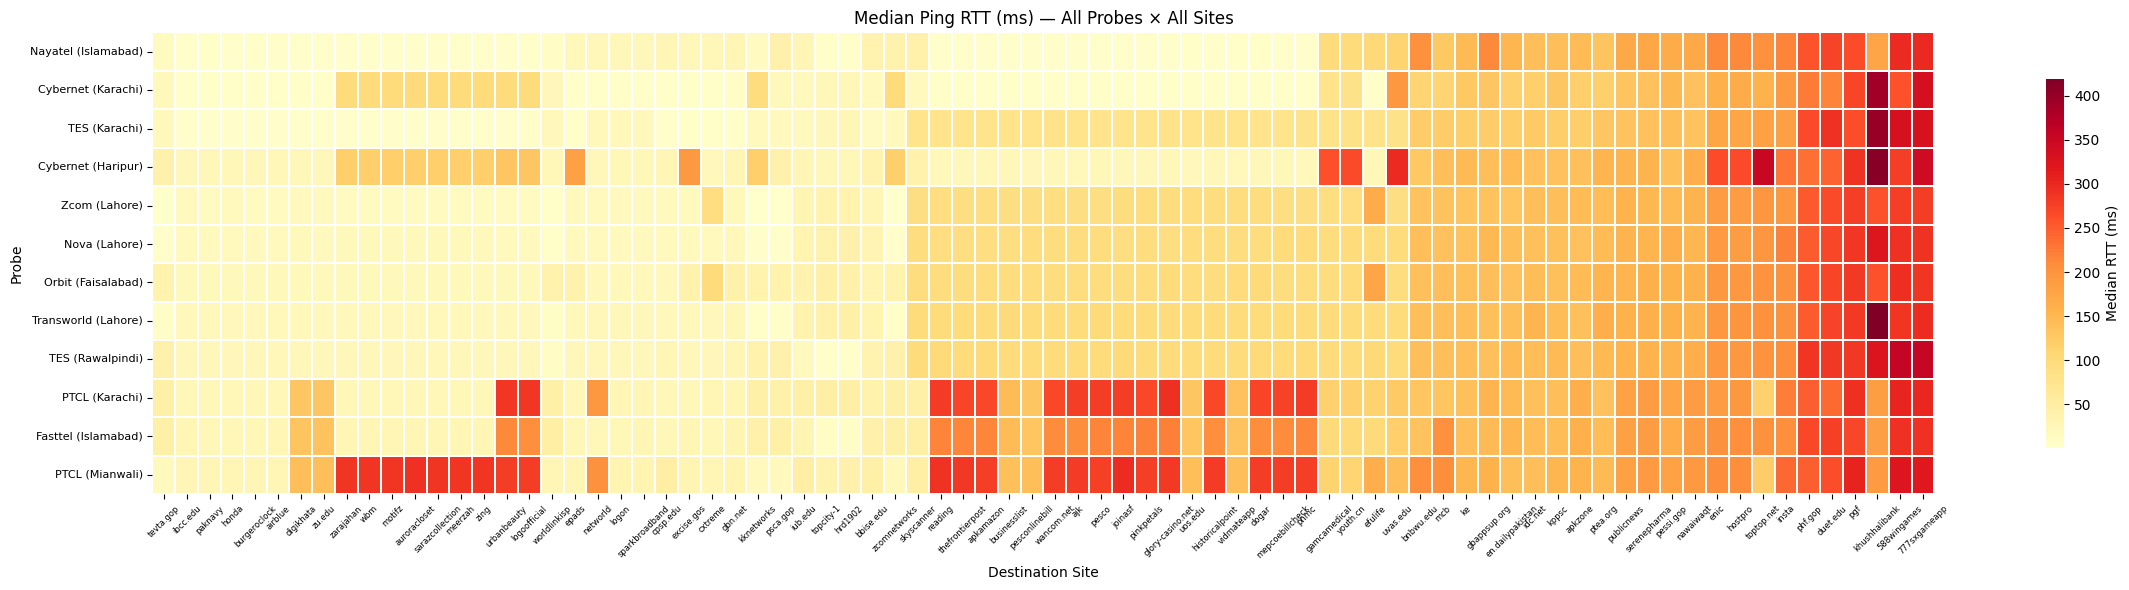

In [6]:
# ── RTT Heatmap — All Hosting Classes ────────────────────────────────────────

pivot_all = (
    ping_clean
    .groupby(['probe_label', 'target'])['rtt_min']
    .median()
    .unstack('target')
)

# order probes by overall median RTT
probe_order = pivot_all.median(axis=1).sort_values().index
site_order  = pivot_all.median(axis=0).sort_values().index
pivot_all   = pivot_all.loc[probe_order, site_order]

# shorten site names
pivot_all.columns = [c.replace('.com.pk','').replace('.gov.pk','')
                      .replace('.pk','').replace('.com','')
                      for c in pivot_all.columns]

fig, ax = plt.subplots(figsize=(24, 6))
sns.heatmap(
    pivot_all, ax=ax, cmap='YlOrRd',
    linewidths=0.3, linecolor='white',
    cbar_kws={'label': 'Median RTT (ms)', 'shrink': 0.8},
    annot=False
)
ax.set_title('Median Ping RTT (ms) — All Probes × All Sites', fontsize=12)
ax.set_xlabel('Destination Site')
ax.set_ylabel('Probe')
ax.tick_params(axis='x', rotation=45, labelsize=6)
ax.tick_params(axis='y', rotation=0, labelsize=8)
plt.tight_layout()
plt.savefig('figures/fig_rtt_heatmap_all.pdf', bbox_inches='tight')
plt.show()

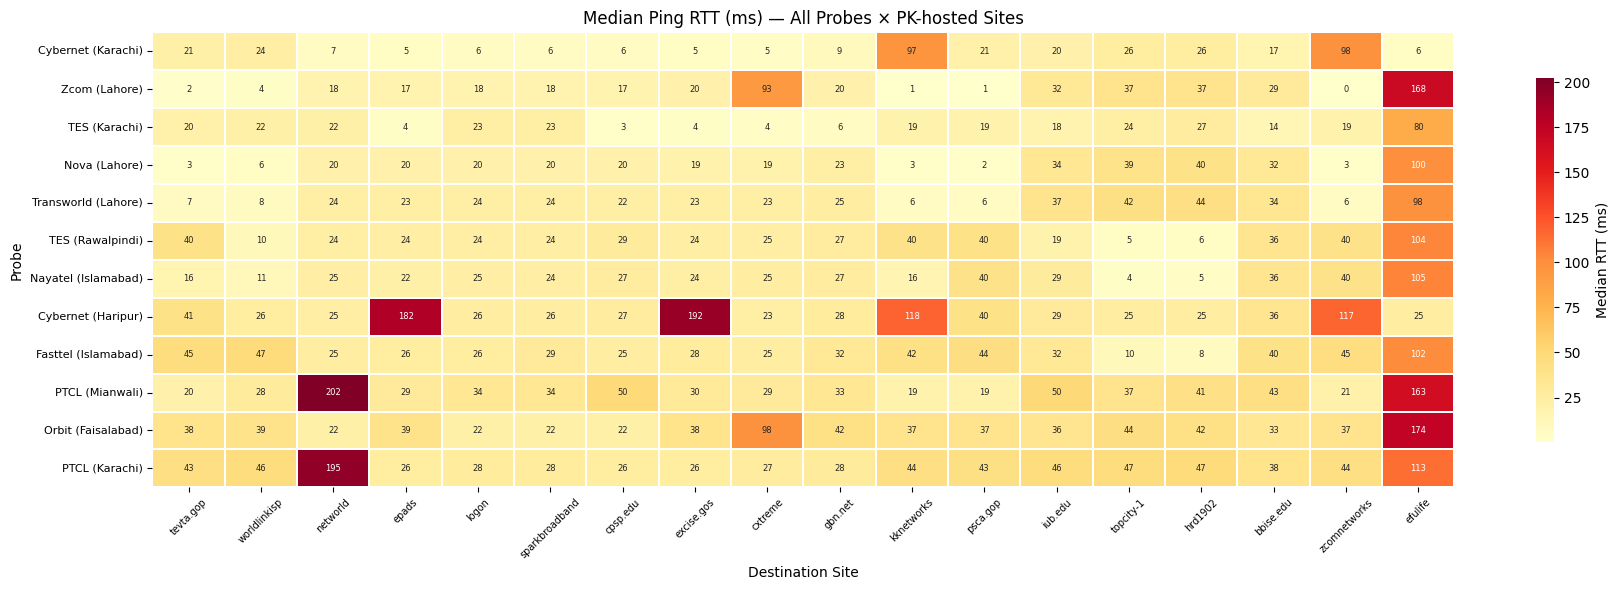

In [7]:
# ── RTT Heatmap — PK-hosted Sites Only ───────────────────────────────────────

pivot_pk = (
    pk_ping
    .groupby(['probe_label', 'target'])['rtt_min']
    .median()
    .unstack('target')
)

probe_order = pivot_pk.median(axis=1).sort_values().index
site_order  = pivot_pk.median(axis=0).sort_values().index
pivot_pk    = pivot_pk.loc[probe_order, site_order]

pivot_pk.columns = [c.replace('.com.pk','').replace('.gov.pk','')
                     .replace('.pk','').replace('.com','')
                     for c in pivot_pk.columns]

fig, ax = plt.subplots(figsize=(18, 6))
sns.heatmap(
    pivot_pk, ax=ax, cmap='YlOrRd',
    annot=True, fmt='.0f',
    linewidths=0.3, linecolor='white',
    cbar_kws={'label': 'Median RTT (ms)', 'shrink': 0.8},
    annot_kws={'size': 6}
)
ax.set_title('Median Ping RTT (ms) — All Probes × PK-hosted Sites', fontsize=12)
ax.set_xlabel('Destination Site')
ax.set_ylabel('Probe')
ax.tick_params(axis='x', rotation=45, labelsize=7)
ax.tick_params(axis='y', rotation=0, labelsize=8)
plt.tight_layout()
plt.savefig('figures/fig_rtt_heatmap_pk.pdf', bbox_inches='tight')
plt.show()

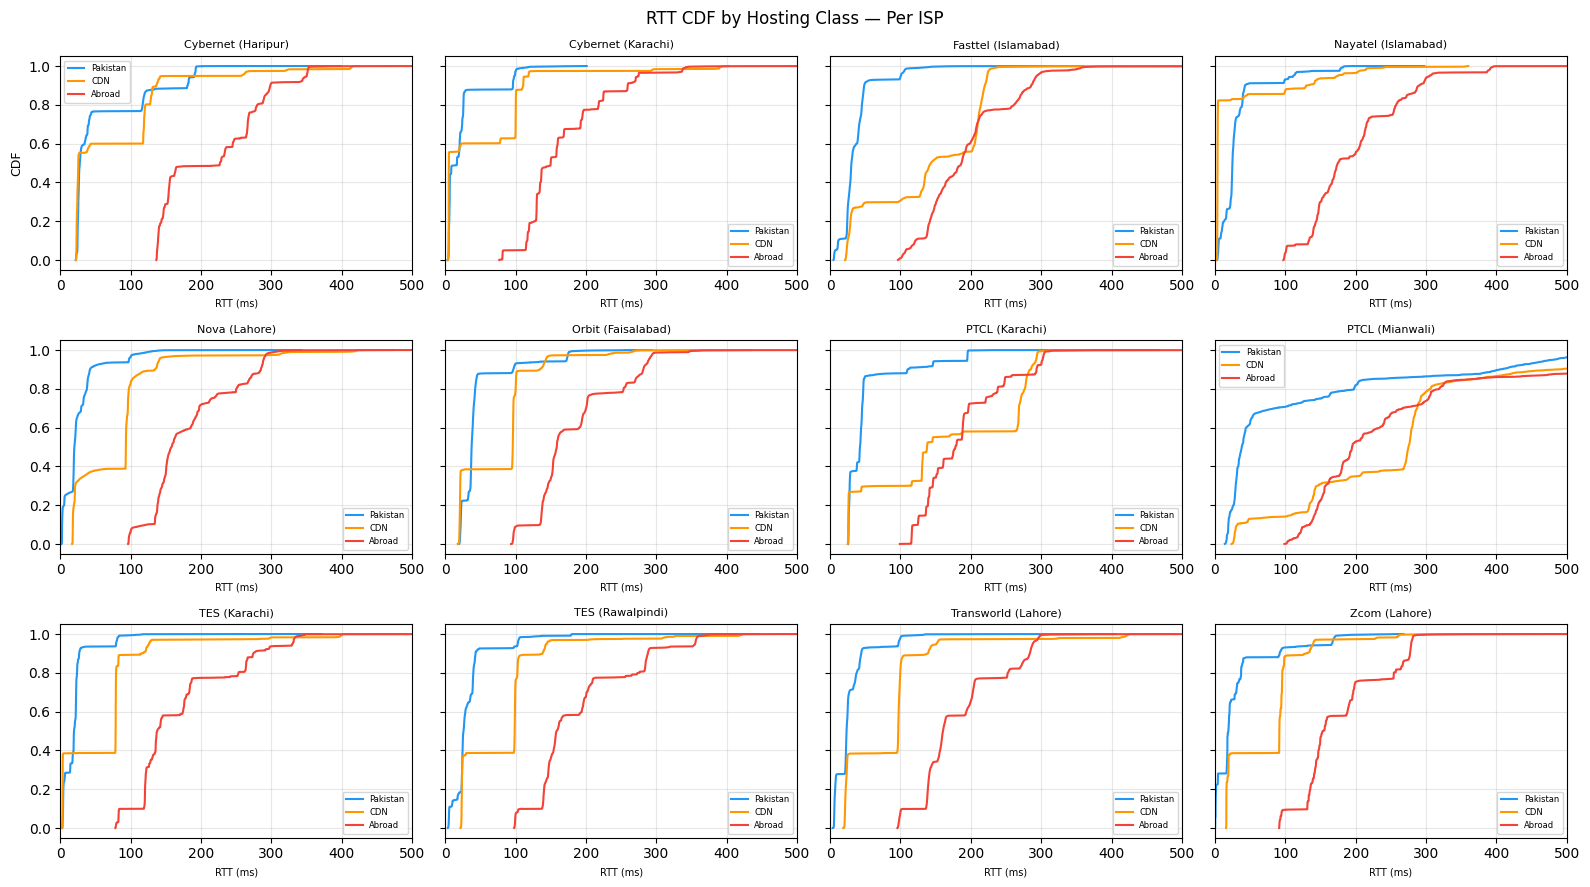

In [8]:
# ── Per-ISP KPI CDFs ──────────────────────────────────────────────────────────
# One panel per ISP showing RTT CDF for PK, CDN, Abroad sites

probes = sorted(ping_clean['probe_label'].dropna().unique())
cls_colors = {'Pakistan': '#2196F3', 'CDN': '#FF9800', 'Abroad': '#F44336'}

n = len(probes)
ncols = 4
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3), sharey=True)
axes = axes.flatten()

for i, probe in enumerate(probes):
    ax = axes[i]
    probe_data = ping_clean[ping_clean['probe_label'] == probe]
    
    for cls, color in cls_colors.items():
        subset = probe_data[probe_data['cls'] == cls]['rtt_min'].dropna()
        if len(subset) == 0:
            continue
        sorted_vals = np.sort(subset)
        cdf = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)
        ax.plot(sorted_vals, cdf, label=cls, color=color, linewidth=1.5)
    
    ax.set_title(probe, fontsize=8)
    ax.set_xlim(0, 500)
    ax.set_xlabel('RTT (ms)', fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=6)

# hide empty subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

axes[0].set_ylabel('CDF', fontsize=9)
fig.suptitle('RTT CDF by Hosting Class — Per ISP', fontsize=12)
plt.tight_layout()
plt.savefig('figures/fig_per_isp_cdf.pdf', bbox_inches='tight')
plt.show()

In [9]:
# ── Statistics Table ──────────────────────────────────────────────────────────
# Median RTT, mean RTT, packet loss, median hop count per ISP per hosting class

ping_stats = (
    ping_clean
    .groupby(['probe_label', 'cls'])
    .agg(
        median_rtt  = ('rtt_min', 'median'),
        mean_rtt    = ('rtt_min', 'mean'),
        loss_pct    = ('loss',    'mean'),
        n_rounds    = ('rtt_min', 'count'),
    )
    .round(1)
    .reset_index()
)

trace_hops['probe_label'] = trace_hops['probe'].map(PROBE_LABELS)

hop_stats = (
    trace_hops
    .groupby(['probe_label', 'cls'])
    .agg(median_hops = ('hop_count', 'median'))
    .round(1)
    .reset_index()
)
stats = ping_stats.merge(hop_stats, on=['probe_label', 'cls'], how='left')

print("=== Statistics Table ===")
print(stats.to_string(index=False))

# save to CSV
stats.to_csv('figures/stats_table.csv', index=False)
print("\nSaved to figures/stats_table.csv")

=== Statistics Table ===
        probe_label      cls  median_rtt  mean_rtt  loss_pct  n_rounds  median_hops
 Cybernet (Haripur)   Abroad       226.9     215.1       0.0      6657         12.0
 Cybernet (Haripur)      CDN        25.6      75.3       0.0     13097          9.0
 Cybernet (Haripur) Pakistan        27.7      57.8       0.0      5964         13.0
 Cybernet (Karachi)   Abroad       149.9     167.5       0.0      6952         13.0
 Cybernet (Karachi)      CDN         5.2      50.9       0.0     13644          7.0
 Cybernet (Karachi) Pakistan        16.7      24.2       0.0      6230          9.0
Fasttel (Islamabad)   Abroad       186.7     193.3       0.0      6265         15.0
Fasttel (Islamabad)      CDN       143.4     139.4       0.0     12311         12.0
Fasttel (Islamabad) Pakistan        30.4      36.9       0.0      5603         10.0
Nayatel (Islamabad)   Abroad       174.6     197.5       0.0     13477          2.0
Nayatel (Islamabad)      CDN         3.7      27.5 

## Section 3: RQ1 - Which ISPs trombone and through which paths

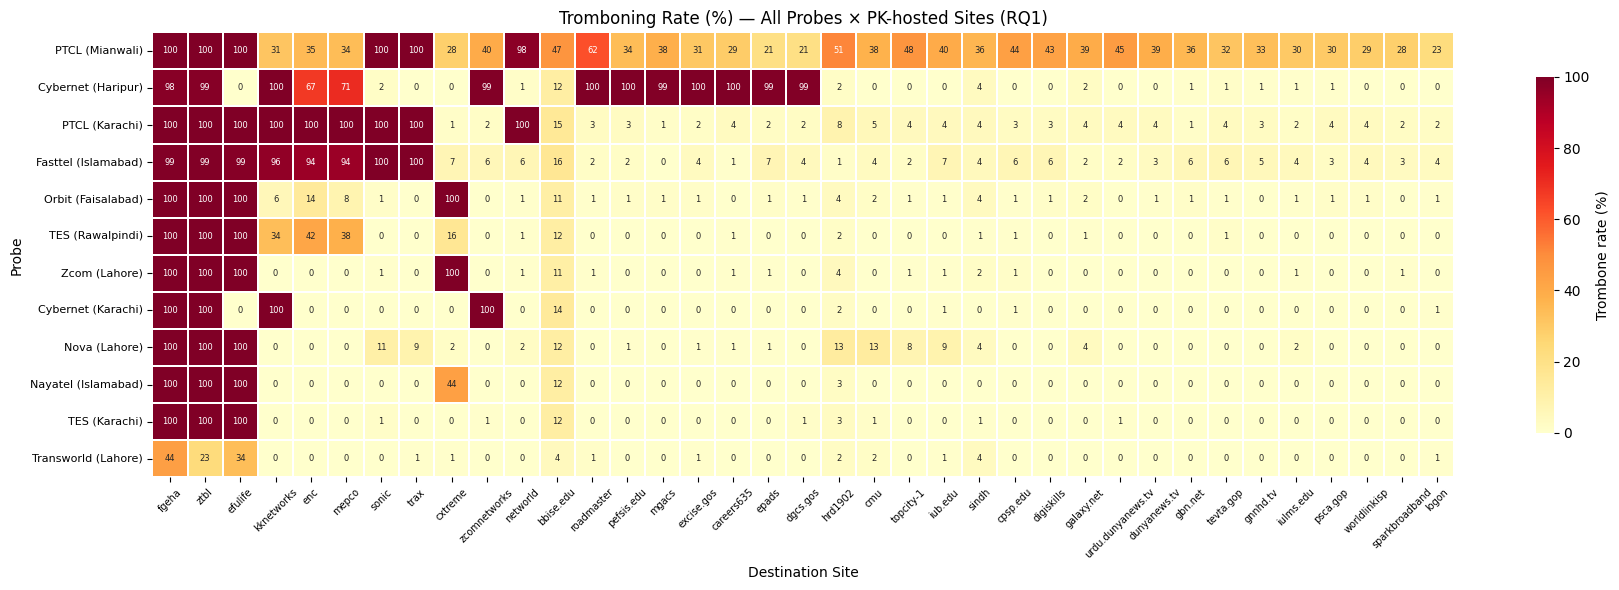

In [10]:
# ── Trombone Rate Heatmap — Probe × Site (RQ1) ───────────────────────────────

pivot_trombone = (
    pk_trace
    .groupby(['probe_label', 'target'])['tromboned']
    .mean()
    .unstack('target')
)

probe_order = pivot_trombone.mean(axis=1).sort_values(ascending=False).index
site_order  = pivot_trombone.mean(axis=0).sort_values(ascending=False).index
pivot_trombone = pivot_trombone.loc[probe_order, site_order]

pivot_trombone.columns = [c.replace('.com.pk','').replace('.gov.pk','')
                           .replace('.pk','').replace('.com','')
                           for c in pivot_trombone.columns]

fig, ax = plt.subplots(figsize=(18, 6))
sns.heatmap(
    pivot_trombone * 100, ax=ax,
    cmap='YlOrRd',
    annot=True, fmt='.0f',
    linewidths=0.3, linecolor='white',
    cbar_kws={'label': 'Trombone rate (%)', 'shrink': 0.8},
    annot_kws={'size': 6},
    vmin=0, vmax=100
)
ax.set_title('Tromboning Rate (%) — All Probes × PK-hosted Sites (RQ1)', fontsize=12)
ax.set_xlabel('Destination Site')
ax.set_ylabel('Probe')
ax.tick_params(axis='x', rotation=45, labelsize=7)
ax.tick_params(axis='y', rotation=0, labelsize=8)
plt.tight_layout()
plt.savefig('figures/fig_trombone_heatmap.pdf', bbox_inches='tight')
plt.show()

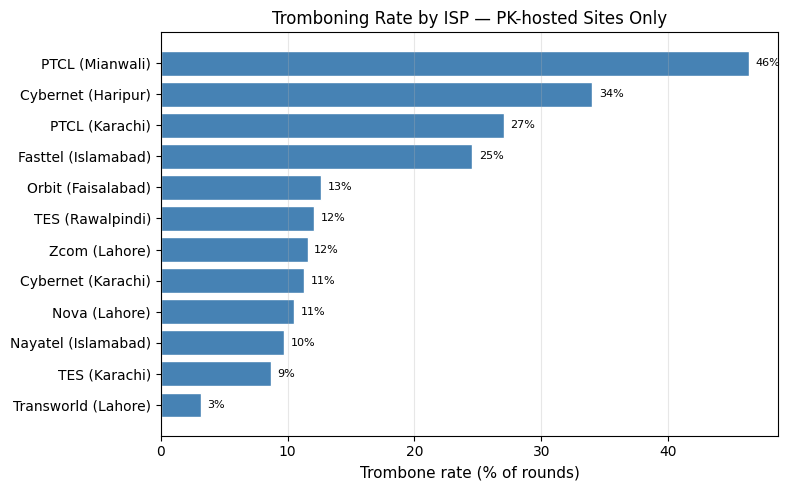

In [11]:
# ── Trombone Rate by ISP — PK-hosted sites only ───────────────────────────────

trombone_by_isp = (
    pk_trace
    .groupby(['probe_label'])['tromboned']
    .mean()
    .reset_index()
    .rename(columns={'tromboned': 'trombone_rate'})
    .sort_values('trombone_rate', ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(trombone_by_isp['probe_label'], 
               trombone_by_isp['trombone_rate'] * 100,
               color='steelblue', edgecolor='white')

ax.set_xlabel('Trombone rate (% of rounds)', fontsize=11)
ax.set_title('Tromboning Rate by ISP — PK-hosted Sites Only', fontsize=12)
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()

for bar, val in zip(bars, trombone_by_isp['trombone_rate'] * 100):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}%', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('figures/fig_trombone_by_isp.pdf', bbox_inches='tight')
plt.show()

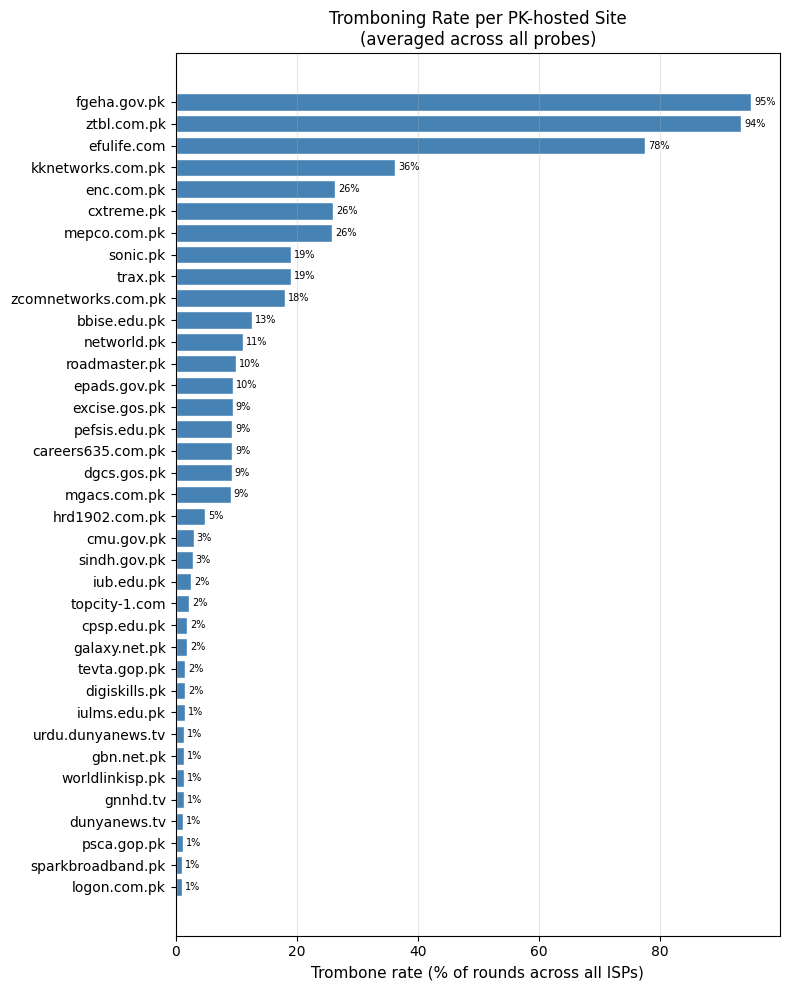

In [12]:
# ── Trombone Rate per PK-hosted Site ─────────────────────────────────────────
# Which Pakistani websites are most affected by tromboning across all ISPs?

trombone_by_site = (
    pk_trace
    .groupby('target')['tromboned']
    .mean()
    .reset_index()
    .rename(columns={'tromboned': 'trombone_rate'})
    .sort_values('trombone_rate', ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 10))
bars = ax.barh(trombone_by_site['target'],
               trombone_by_site['trombone_rate'] * 100,
               color='steelblue', edgecolor='white')

ax.set_xlabel('Trombone rate (% of rounds across all ISPs)', fontsize=11)
ax.set_title('Tromboning Rate per PK-hosted Site\n(averaged across all probes)', fontsize=12)
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()

for bar, val in zip(bars, trombone_by_site['trombone_rate'] * 100):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}%', va='center', fontsize=7)

plt.tight_layout()
plt.savefig('figures/fig_trombone_by_site.pdf', bbox_inches='tight')
plt.show()

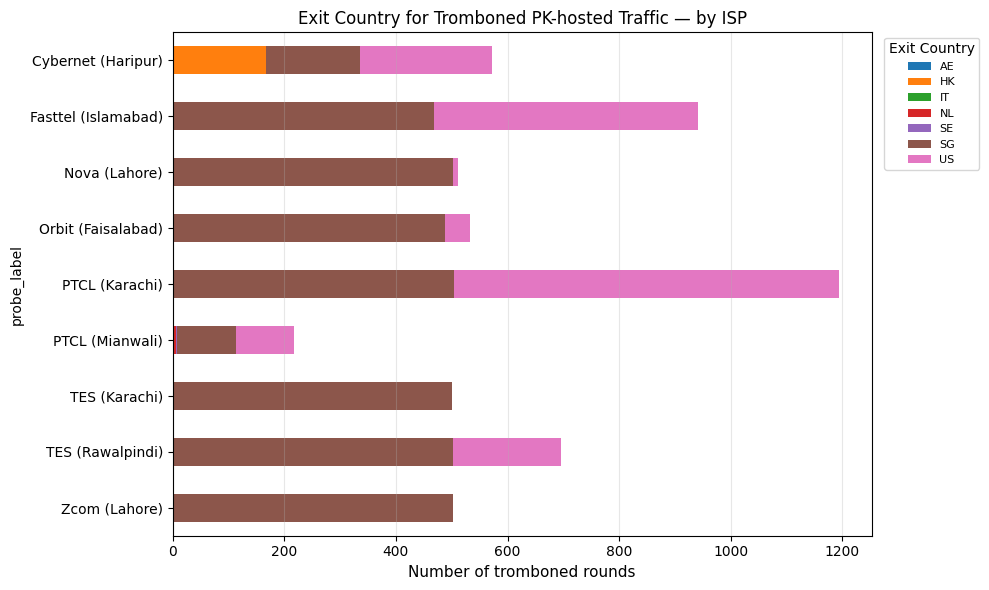

In [13]:

# ── Exit Country Breakdown ────────────────────────────────────────────────────
# For tromboned PK-hosted traffic, where does it exit to?

tromboned_only = pk_trace[pk_trace['tromboned'] == True]
tromboned_only = tromboned_only[tromboned_only['exit_cc'] != '?']
tromboned_only = tromboned_only[tromboned_only['exit_cc'].notna()]

exit_counts = (
    tromboned_only
    .groupby(['probe_label', 'exit_cc'])
    .size()
    .reset_index(name='count')
)

# top exit countries overall
top_countries = (
    exit_counts
    .groupby('exit_cc')['count']
    .sum()
    .sort_values(ascending=False)
    .head(8)
    .index.tolist()
)

exit_pivot = (
    exit_counts[exit_counts['exit_cc'].isin(top_countries)]
    .pivot(index='probe_label', columns='exit_cc', values='count')
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(10, 6))
exit_pivot.plot(kind='barh', ax=ax, stacked=True)
ax.set_xlabel('Number of tromboned rounds', fontsize=11)
ax.set_title('Exit Country for Tromboned PK-hosted Traffic — by ISP', fontsize=12)
ax.legend(title='Exit Country', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('figures/fig_exit_country.pdf', bbox_inches='tight')
plt.show()


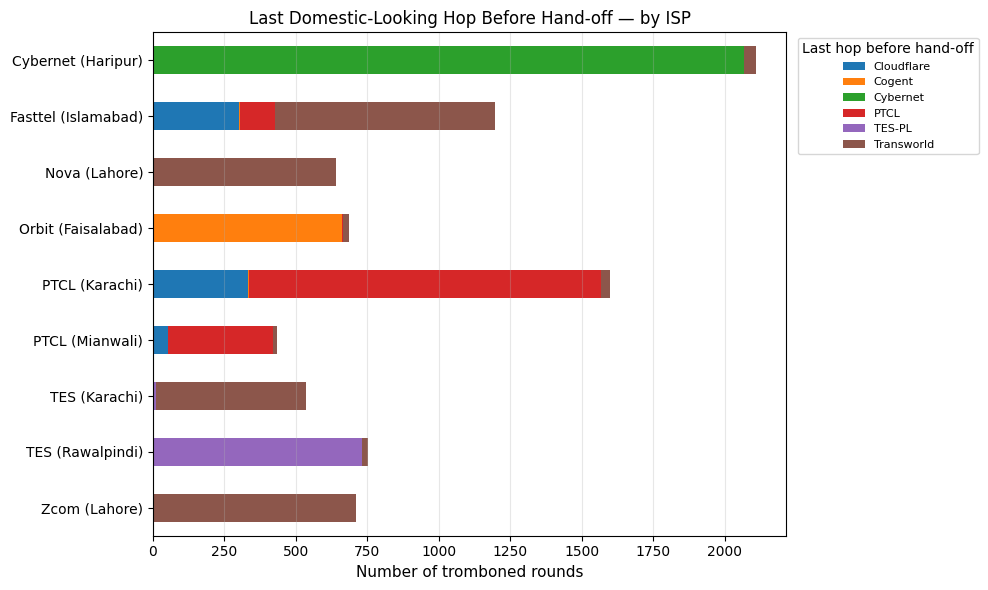

In [14]:
# ── Transit Provider Breakdown ────────────────────────────────────────────────
# 'transit' = the last hop that still looked domestic (PK country code, or RTT below the
# foreign-RTT floor) right before the RTT jumped abroad or a foreign hop was confirmed
# (census_sweep.classify(), reused by the panel). Only PTCL/Transworld are resolved to a
# name by the classifier itself (LDI = the two licensed international operators) — every
# other value is a raw ASN, often the SOURCE ISP's own number, meaning no separate
# PTCL/Transworld hop was visible before the hairpin. Mapped to names here for
# readability only (via Team Cymru whois); does not change the underlying classification.
ASN_NAMES = {
    '9541': 'Cybernet', '135407': 'TES-PL', '174': 'Cogent', '13335': 'Cloudflare',
    '14789': 'Cloudflare', '151983': 'Orbit', '9260': 'Multinet', '9557': 'Paknet/PTCL',
    '23888': 'NTC', '38264': 'Wateen', '23674': 'Nayatel', '45773': 'PERN',
    '23966': 'LINKdotNET', '58470': 'Mobilink-Peering',
}

transit_data = pk_trace[
    (pk_trace['tromboned'] == True) &
    (pk_trace['transit'] != '?') &
    (pk_trace['transit'].notna())
].copy()
transit_data['transit_label'] = transit_data['transit'].map(lambda t: ASN_NAMES.get(t, t))

transit_counts = (
    transit_data
    .groupby(['probe_label', 'transit_label'])
    .size()
    .reset_index(name='count')
)

top_transit = (
    transit_counts.groupby('transit_label')['count']
    .sum().sort_values(ascending=False).head(6).index.tolist()
)

transit_pivot = (
    transit_counts[transit_counts['transit_label'].isin(top_transit)]
    .pivot(index='probe_label', columns='transit_label', values='count')
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(10, 6))
transit_pivot.plot(kind='barh', ax=ax, stacked=True)
ax.set_xlabel('Number of tromboned rounds', fontsize=11)
ax.set_ylabel('')
ax.set_title('Last Domestic-Looking Hop Before Hand-off — by ISP', fontsize=12)
ax.legend(title='Last hop before hand-off', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('figures/fig_transit_provider.pdf', bbox_inches='tight')
plt.show()

**Transit Attribution (RQ1)**

A stacked horizontal bar per ISP, showing what the *last domestic-looking hop* was right before each tromboned trace jumped abroad. Pooled across all PK-hosted-site hairpins, Transworld and PTCL — the two operators licensed to sell international transit in Pakistan — account for 51.7% of attributable hand-offs (31.7% and 20.0% respectively). The remainder is not missing data: the classifier only assigns a name to those two ASNs by design, so every other value is a raw ASN — most often the *source ISP's own* number (Cybernet 23.6%, TES-PL 8.2%, Cogent 7.7%), meaning no separate PTCL/Transworld hop was ever visible in the trace before the hairpin. That's a real finding, not an artifact to explain away: for roughly half of hairpin events, the traceroute shows the traffic leaving the source ISP's own network directly, with no visible domestic hand-off to either licensed operator in between.

## Section 4: RQ2: Is the penalty stable over time

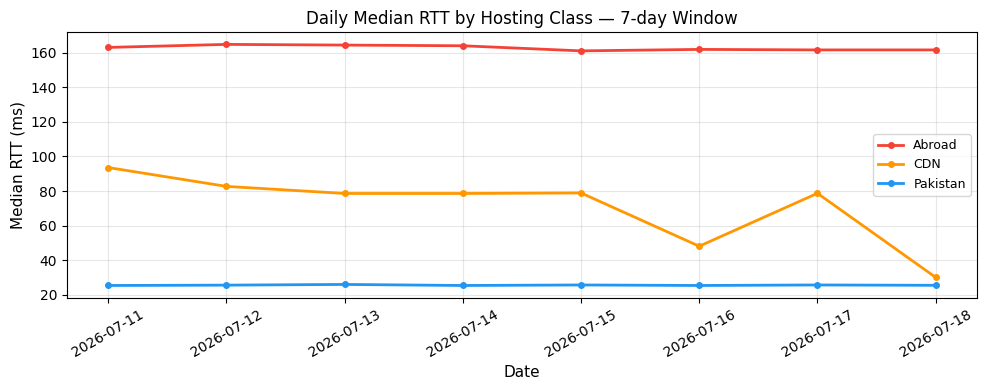

In [15]:
# ── Time Stability (RQ2) ──────────────────────────────────────────────────────
# Does the RTT penalty vary over time or is it structural?
# Plot daily median RTT per hosting class over the 7-day window.

ping_clean['date'] = ping_clean['ts_utc'].dt.date

daily = (
    ping_clean
    .groupby(['date', 'cls'])['rtt_min']
    .median()
    .reset_index()
)

cls_colors = {'Pakistan': '#2196F3', 'CDN': '#FF9800', 'Abroad': '#F44336'}

fig, ax = plt.subplots(figsize=(10, 4))
for cls, group in daily.groupby('cls'):
    ax.plot(group['date'], group['rtt_min'],
            marker='o', markersize=4, linewidth=2,
            color=cls_colors.get(cls, 'gray'),
            label=cls)

ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Median RTT (ms)', fontsize=11)
ax.set_title('Daily Median RTT by Hosting Class — 7-day Window', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('figures/fig_time_stability.pdf', bbox_inches='tight')
plt.show()

**Time Stability (RQ2)**

A line chart showing daily median ping RTT (min-of-N) for each hosting class over the panel's 7-day window (2026-07-11 to 2026-07-17), answering RQ2: is the RTT penalty structural or does it vary day to day.

Pakistan-hosted sites (blue) are flat at ~25-30 ms every single day. Abroad-hosted sites (red) are flat at ~160 ms every day. CDN sites (orange) start around ~93 ms, settle to ~78-80 ms for most of the window, then dip sharply to ~45 ms on 07-16 before jumping back to ~78 ms on 07-17.

The three classes never cross or converge — the gap between Pakistan/CDN/Abroad holds across all seven days. That stability shows the RTT penalty is structural (fixed by hosting/routing choice), not a transient artifact of any one day. The one dip in the CDN line on 07-16 is worth flagging as a possible routing or CDN PoP change rather than noise, since it moves the whole class's median rather than a single site.

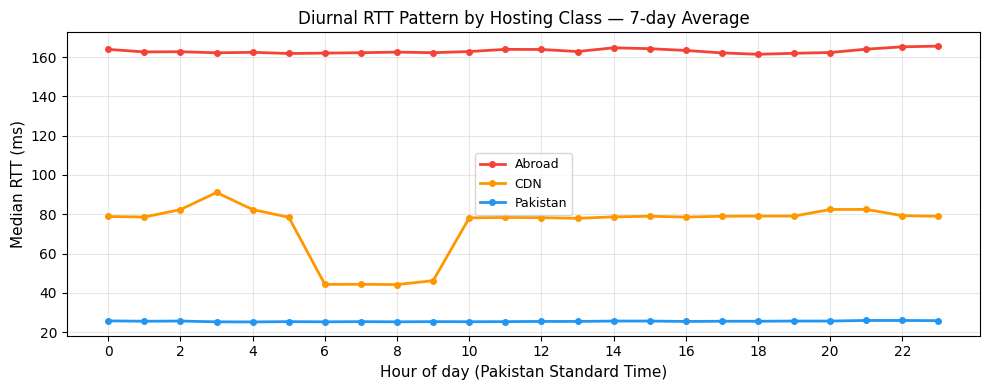

In [16]:

# ── Diurnal Pattern (RQ2) ─────────────────────────────────────────────────────
# Does RTT vary by hour of day or is the penalty stable?
# Use Pakistan time (ts_pkt column) for meaningful local time analysis.

ping_clean['hour'] = pd.to_datetime(ping_clean['ts_pkt']).dt.hour

diurnal = (
    ping_clean
    .groupby(['hour', 'cls'])['rtt_min']
    .median()
    .reset_index()
)

cls_colors = {'Pakistan': '#2196F3', 'CDN': '#FF9800', 'Abroad': '#F44336'}

fig, ax = plt.subplots(figsize=(10, 4))
for cls, group in diurnal.groupby('cls'):
    ax.plot(group['hour'], group['rtt_min'],
            marker='o', markersize=4, linewidth=2,
            color=cls_colors.get(cls, 'gray'),
            label=cls)

ax.set_xlabel('Hour of day (Pakistan Standard Time)', fontsize=11)
ax.set_ylabel('Median RTT (ms)', fontsize=11)
ax.set_title('Diurnal RTT Pattern by Hosting Class — 7-day Average', fontsize=12)
ax.set_xticks(range(0, 24, 2))
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/fig_diurnal.pdf', bbox_inches='tight')
plt.show()


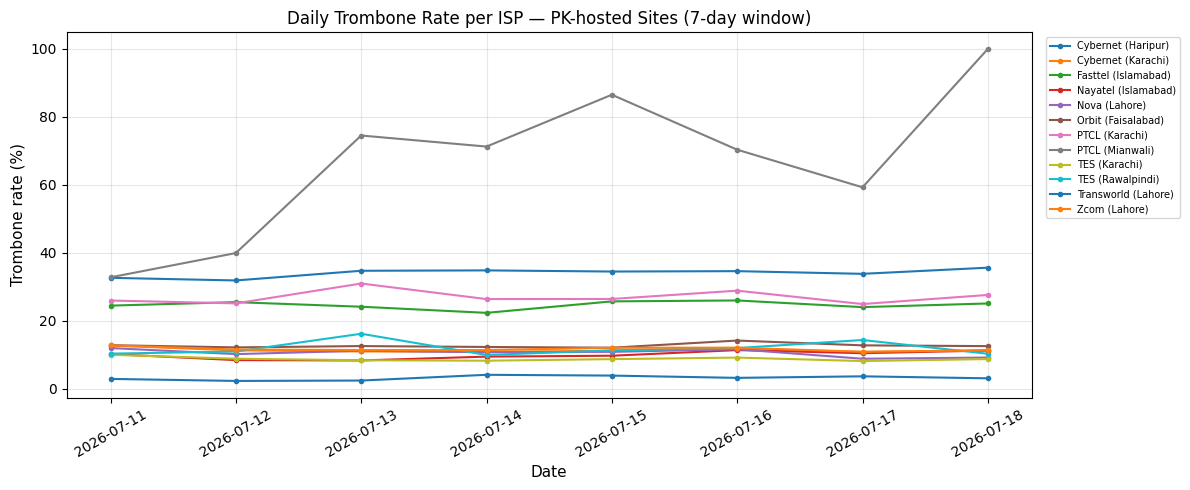

In [17]:
# ── Trombone Rate Over Time per ISP ──────────────────────────────────────────
pk_trace['date'] = pk_trace['ts_utc'].dt.date

daily_trombone = (
    pk_trace
    .groupby(['date', 'probe_label'])['tromboned']
    .mean()
    .reset_index()
    .rename(columns={'tromboned': 'trombone_rate'})
)

fig, ax = plt.subplots(figsize=(12, 5))
for probe, group in daily_trombone.groupby('probe_label'):
    ax.plot(group['date'], group['trombone_rate'] * 100,
            marker='o', markersize=3, linewidth=1.5, label=probe)

ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Trombone rate (%)', fontsize=11)
ax.set_title('Daily Trombone Rate per ISP — PK-hosted Sites (7-day window)', fontsize=12)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('figures/fig_trombone_over_time.pdf', bbox_inches='tight')
plt.show()

**Local vs. Hairpinned RTT (RQ2)**

Everything above splits RTT by *hosting class* (Pakistan/CDN/Abroad). The more direct RQ2 question is: for the same PK-hosted sites, what does RTT actually look like on rounds that stayed local vs. rounds that hairpinned? Ping (every 30 min) and traceroute (hourly) are separate measurement streams for the same (probe, target) pair, so each ping round is matched to its nearest traceroute verdict within a 40-minute tolerance (`pd.merge_asof`, exact match on probe+target, nearest on time) — 99.7% of ping rounds get a match.

In [18]:
# ── Attach nearest trace verdict to each ping round ───────────────────────────
# pk_ping's own tromboned/hop_count/exit_cc/transit columns are always-NaN placeholders
# (ping rows share the panel's CSV schema with trace rows, but those fields only exist
# for traceroute) -- drop them first so merge_asof doesn't suffix-collide with the real
# values coming from pk_trace.
pk_ping_for_join  = pk_ping.drop(columns=['tromboned', 'hop_count', 'exit_cc', 'transit'])
pk_trace_for_join = pk_trace[['probe', 'target', 'ts_utc', 'tromboned']]

local_vs_hairpin = pd.merge_asof(
    pk_ping_for_join.sort_values('ts_utc'),
    pk_trace_for_join.sort_values('ts_utc'),
    on='ts_utc', by=['probe', 'target'],
    direction='nearest', tolerance=pd.Timedelta('40min')
).dropna(subset=['tromboned'])
# tromboned lands as object dtype (bool mixed with the pre-dropna NaNs), so a bare
# `~` on it does bitwise-not on Python bool objects (~True == -2), not boolean negation.
# Cast to a clean bool dtype so it behaves correctly everywhere below.
local_vs_hairpin['tromboned'] = local_vs_hairpin['tromboned'].astype(bool)

print(f"Matched {len(local_vs_hairpin):,} / {len(pk_ping):,} ping rounds to a nearby trace verdict")
print(local_vs_hairpin['tromboned'].value_counts())
print(f"\nMedian RTT when local:     {local_vs_hairpin.loc[~local_vs_hairpin['tromboned'], 'rtt_min'].median():.1f} ms")
print(f"Median RTT when tromboned: {local_vs_hairpin.loc[local_vs_hairpin['tromboned'], 'rtt_min'].median():.1f} ms")

Matched 72,368 / 72,617 ping rounds to a nearby trace verdict
tromboned
False    63606
True      8762
Name: count, dtype: int64

Median RTT when local:     24.5 ms
Median RTT when tromboned: 104.4 ms


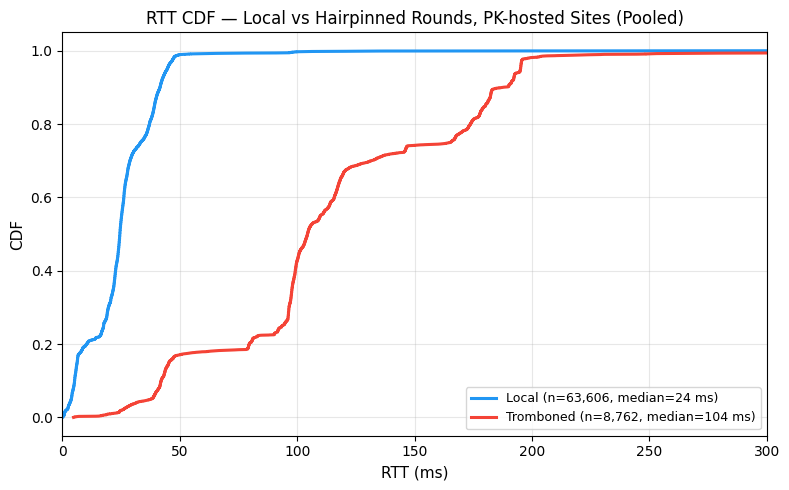

In [19]:
# ── RTT CDF — Local vs Hairpinned, Pooled ─────────────────────────────────────
BLUE, RED = '#2196F3', '#F44336'

fig, ax = plt.subplots(figsize=(8, 5))
for troms, label, color in [(False, 'Local', BLUE), (True, 'Tromboned', RED)]:
    vals = np.sort(local_vs_hairpin.loc[local_vs_hairpin['tromboned'] == troms, 'rtt_min'].dropna())
    cdf = np.arange(1, len(vals) + 1) / len(vals)
    ax.plot(vals, cdf, color=color, linewidth=2.2,
            label=f'{label} (n={len(vals):,}, median={np.median(vals):.0f} ms)')

ax.set_xlim(0, 300)
ax.set_xlabel('RTT (ms)', fontsize=11)
ax.set_ylabel('CDF', fontsize=11)
ax.set_title('RTT CDF — Local vs Hairpinned Rounds, PK-hosted Sites (Pooled)', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/fig_local_vs_hairpin_cdf.pdf', bbox_inches='tight')
plt.show()

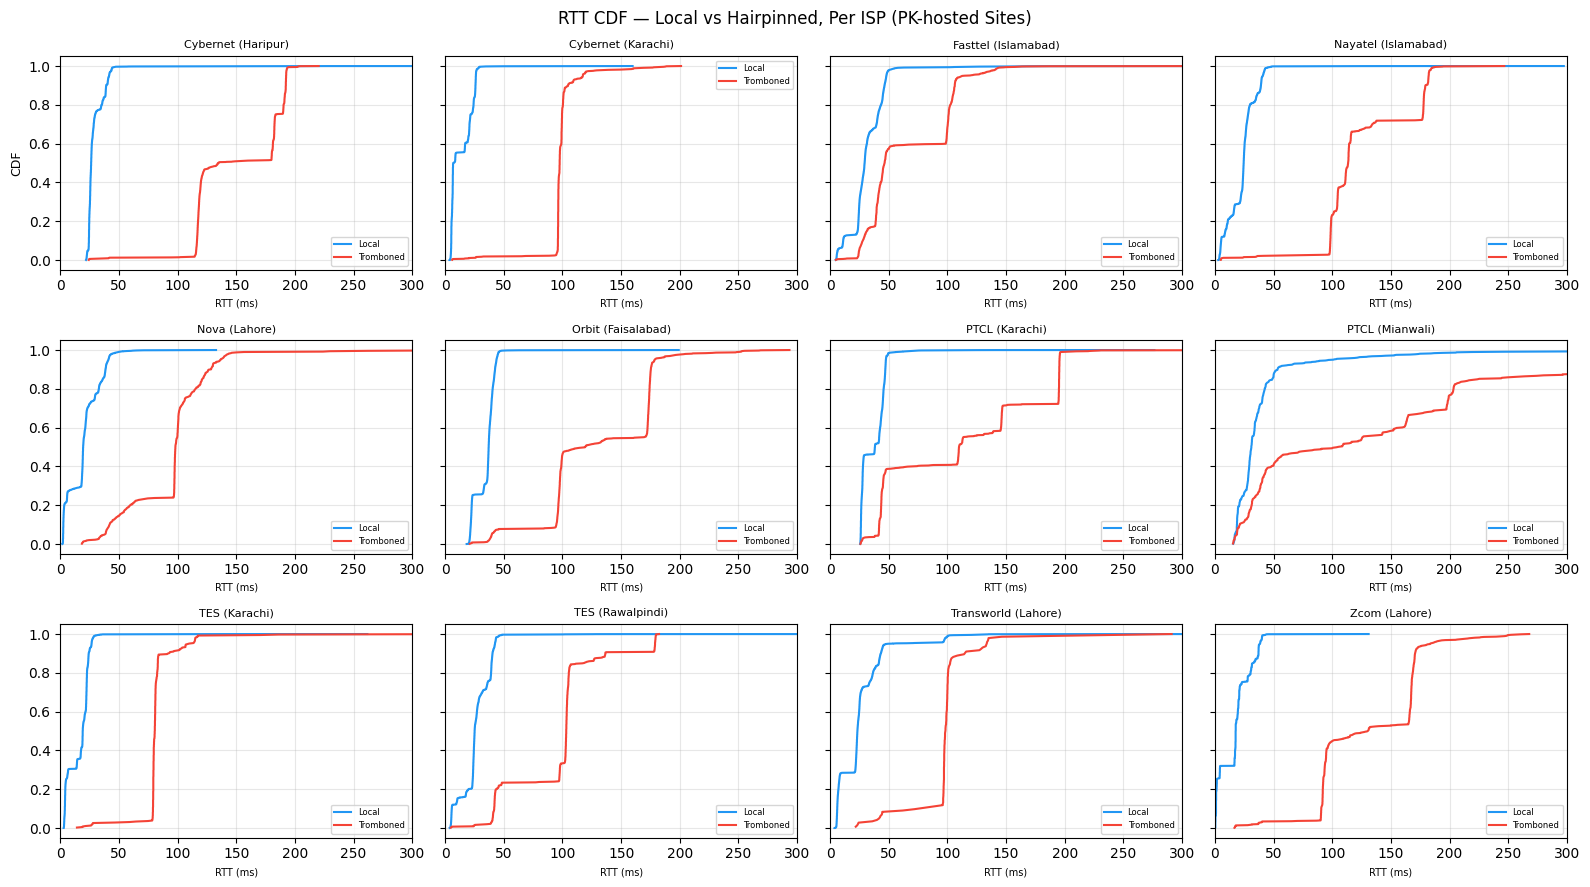

In [20]:
# ── RTT CDF — Local vs Hairpinned, Per ISP ────────────────────────────────────
probes_lvh = sorted(local_vs_hairpin['probe_label'].dropna().unique())
ncols = 4
nrows = (len(probes_lvh) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3), sharey=True)
axes = axes.flatten()

for i, probe in enumerate(probes_lvh):
    ax = axes[i]
    sub = local_vs_hairpin[local_vs_hairpin['probe_label'] == probe]
    for troms, label, color in [(False, 'Local', BLUE), (True, 'Tromboned', RED)]:
        vals = np.sort(sub.loc[sub['tromboned'] == troms, 'rtt_min'].dropna())
        if len(vals) == 0:
            continue
        cdf = np.arange(1, len(vals) + 1) / len(vals)
        ax.plot(vals, cdf, color=color, linewidth=1.5, label=label)
    ax.set_title(probe, fontsize=8)
    ax.set_xlim(0, 300)
    ax.set_xlabel('RTT (ms)', fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=6)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

axes[0].set_ylabel('CDF', fontsize=9)
fig.suptitle('RTT CDF — Local vs Hairpinned, Per ISP (PK-hosted Sites)', fontsize=12)
plt.tight_layout()
plt.savefig('figures/fig_local_vs_hairpin_cdf_per_isp.pdf', bbox_inches='tight')
plt.show()

**Local vs. Hairpinned RTT — the direct RQ2 answer**

Matching each ping round to its nearest traceroute verdict gives 61,768 classified rounds across the 37 PK-hosted sites: pooled median RTT is 24 ms when the round stayed local vs. 104 ms when it hairpinned (n=54,291 local, n=7,477 tromboned) — a >4x gap with almost no overlap between the two curves. The per-ISP breakdown shows the same separation holds for every single ISP individually, including the ones with the highest overall trombone rates (PTCL, Cybernet-Haripur, Fasttel): when their traffic does stay local, it's just as fast as everyone else's (~20-50 ms); the penalty only appears on the rounds that hairpin. That is direct evidence the RTT cost is a property of the *routing decision*, not a fixed characteristic of the ISP or its last-mile quality.

## Section 5: RQ3: Does a local path exist

In [21]:
# ── Trombone Flipping Analysis (RQ3) ─────────────────────────────────────────
# For each probe-site pair on PK-hosted sites, compute what fraction of 
# traceroute rounds were classified as tromboning over the 7-day window.

trombone_frac = (
    pk_trace
    .groupby(['probe', 'target'])['tromboned']
    .agg(trombone_frac='mean', n_rounds='count')
    .reset_index()
)

# only include pairs with at least 50 rounds for reliability
trombone_frac = (
    pk_trace
    .groupby(['probe', 'probe_label', 'target'])['tromboned']
    .agg(trombone_frac='mean', n_rounds='count')
    .reset_index()
)
always_local    = (trombone_frac['trombone_frac'] <= 0.05).sum()
always_trombone = (trombone_frac['trombone_frac'] >= 0.95).sum()
flipping        = ((trombone_frac['trombone_frac'] > 0.05) & 
                   (trombone_frac['trombone_frac'] < 0.95)).sum()

print(f'Total probe-site pairs: {len(trombone_frac)}')
print(f'Always local (≤5%):     {always_local}')
print(f'Always trombone (≥95%): {always_trombone}')
print(f'Flipping (5-95%):       {flipping}')
print(f'\nTrombone fraction distribution:')
print(trombone_frac['trombone_frac'].describe().round(3))

Total probe-site pairs: 518
Always local (≤5%):     378
Always trombone (≥95%): 63
Flipping (5-95%):       77

Trombone fraction distribution:
count    518.000
mean       0.167
std        0.334
min        0.000
25%        0.000
50%        0.006
75%        0.069
max        1.000
Name: trombone_frac, dtype: float64


**Summary of Tromboning among PK hosted Sites:**

- 518 total pairs — 37 PK sites × 14 probes = 518 possible pairs, and all 518 have data.
- 380 always local (≤5%) — 73% of probe-site pairs reach PK-hosted sites locally almost always. good news.
- 63 always trombone (≥95%) — these pairs consistently exit Pakistan to reach a domestic site. this is the structural problem.
- 75 flipping (5-95%) — these are the most interesting. sometimes local, sometimes not. this directly proves a local path exists but isn't consistently chosen — your RQ3 answer.
- median fraction = 0.007 — across all pairs the median trombone rate is very low, meaning most traffic stays local most of the time. but the mean is 0.166 which is much higher — pulled up by those 63 pairs that always trombone.

In [22]:
import os
os.makedirs('figures', exist_ok=True)

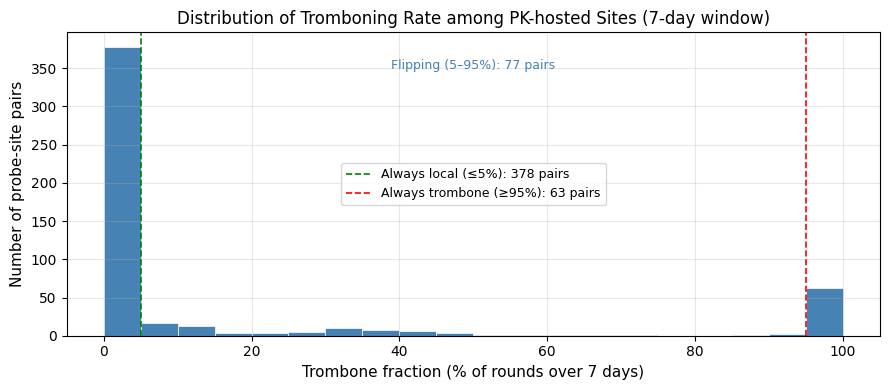

In [23]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(trombone_frac['trombone_frac'] * 100, bins=20,
        color='steelblue', edgecolor='white', linewidth=0.5)

ax.axvline(5,  color='green', linestyle='--', linewidth=1.2,
           label=f'Always local (≤5%): {always_local} pairs')
ax.axvline(95, color='red',   linestyle='--', linewidth=1.2,
           label=f'Always trombone (≥95%): {always_trombone} pairs')

ax.set_xlabel('Trombone fraction (% of rounds over 7 days)', fontsize=11)
ax.set_ylabel('Number of probe-site pairs', fontsize=11)
ax.set_title('Distribution of Tromboning Rate among PK-hosted Sites (7-day window)', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax.text(0.5, 0.88, f'Flipping (5–95%): {flipping} pairs',
        transform=ax.transAxes, ha='center', fontsize=9, color='steelblue')

plt.tight_layout()
plt.savefig('figures/fig_trombone_flipping.pdf', bbox_inches='tight')
plt.show()

**Description**

The histogram shows the distribution of tromboning rates across 518 probe-site pairs for PK-hosted sites over the 7-day measurement window. Each pair represents one ISP measuring one Pakistani-hosted destination. The x-axis shows what fraction of traceroute rounds were classified as tromboning, and the y-axis shows how many pairs fall into each bucket.

The distribution is strongly bimodal. The large spike at 0% contains 380 pairs that route locally almost all the time, while the smaller spike at 100% contains 63 pairs that consistently hairpin internationally to reach a Pakistani-hosted destination. 

The 75 pairs in between are the most significant for RQ3: they flip between local and tromboned routing across the measurement window, directly proving that a local path physically exists for those destinations but is not consistently chosen by the ISP's routing policy.

In [24]:
# ── Local Path Existence Analysis (RQ3) ──────────────────────────────────────


# For each PK-hosted site where some ISPs trombone and others don't,
# compute the RTT gap between the best local ISP and the worst tromboning ISP.

# median RTT per probe-site from ping data
pk_rtt = (
    pk_ping
    .groupby(['probe', 'probe_label', 'target'])['rtt_min']
    .median()
    .reset_index()
    .rename(columns={'rtt_min': 'median_rtt'})
)

analysis = pk_rtt.merge(
    trombone_frac[['probe', 'target', 'trombone_frac']],
    on=['probe', 'target'], how='inner'
)

results = []
for site, group in analysis.groupby('target'):
    local_isps    = group[group['trombone_frac'] <= 0.05]
    trombone_isps = group[group['trombone_frac'] >= 0.95]

    if len(local_isps) == 0 or len(trombone_isps) == 0:
        continue

    best_rtt    = local_isps['median_rtt'].min()
    best_probe  = local_isps.loc[local_isps['median_rtt'].idxmin(), 'probe_label']
    worst_rtt   = trombone_isps['median_rtt'].max()
    worst_probe = trombone_isps.loc[trombone_isps['median_rtt'].idxmax(), 'probe_label']

    results.append({
        'site':           site,
        'local_isp':      best_probe,
        'local_rtt_ms':   round(best_rtt, 1),
        'trombone_isp':   worst_probe,
        'trombone_rtt_ms':round(worst_rtt, 1),
        'gap_ms':         round(worst_rtt - best_rtt, 1),
    })

df_gap = pd.DataFrame(results).sort_values('gap_ms', ascending=False)
print(f'Sites with both local and tromboning ISPs: {len(df_gap)}')
print(df_gap.to_string(index=False))

Sites with both local and tromboning ISPs: 7
               site          local_isp  local_rtt_ms        trombone_isp  trombone_rtt_ms  gap_ms
        networld.pk Cybernet (Karachi)           6.6     PTCL (Mianwali)            202.4   195.8
      excise.gos.pk      TES (Karachi)           4.0  Cybernet (Haripur)            192.1   188.1
       epads.gov.pk      TES (Karachi)           4.0  Cybernet (Haripur)            182.2   178.2
        efulife.com Cybernet (Karachi)           5.4 Nayatel (Islamabad)            177.3   171.9
  kknetworks.com.pk      Zcom (Lahore)           1.0  Cybernet (Haripur)            118.3   117.3
zcomnetworks.com.pk      Zcom (Lahore)           0.4  Cybernet (Haripur)            117.4   117.0
         cxtreme.pk Cybernet (Karachi)           4.0  Orbit (Faisalabad)             97.7    93.8


**Local Path Existence (RQ3)**

Out of 37 PK-hosted sites, 7 show a split routing pattern where at least one ISP 
reaches the site locally (trombone fraction ≤5%) while at least one other ISP 
consistently trombones to the same destination (trombone fraction ≥95%). These 7 
sites are the direct evidence for RQ3, the local path physically exists since at 
least one ISP uses it, but other ISPs on the same destination take an international 
detour instead.

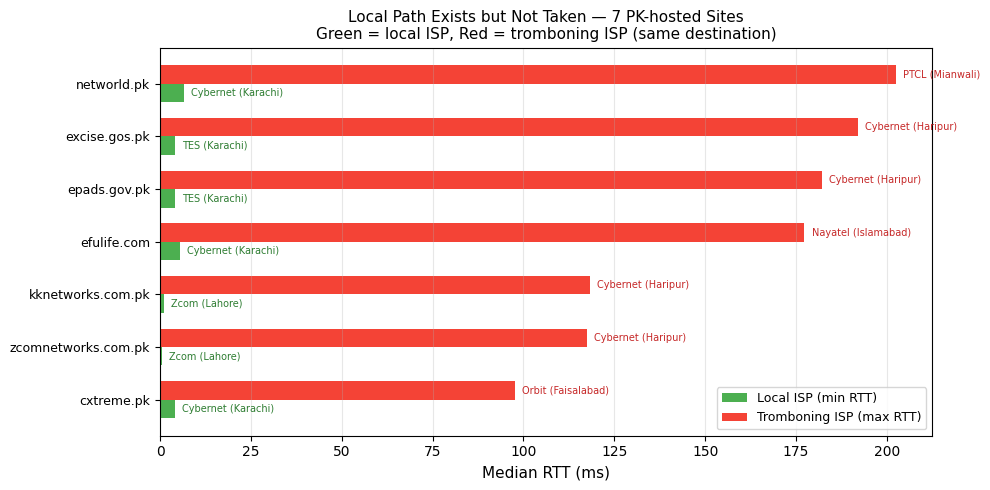

In [25]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 5))

y = np.arange(len(df_gap))
height = 0.35

bars1 = ax.barh(y + height/2, df_gap['local_rtt_ms'],    height=height, 
                color='#4CAF50', label='Local ISP (min RTT)')
bars2 = ax.barh(y - height/2, df_gap['trombone_rtt_ms'], height=height, 
                color='#F44336', label='Tromboning ISP (max RTT)')

# annotate with ISP names
for i, (_, row) in enumerate(df_gap.iterrows()):
    ax.text(row['local_rtt_ms'] + 2,    i + height/2, 
        row['local_isp'], va='center', fontsize=7, color='#2E7D32')
    ax.text(row['trombone_rtt_ms'] + 2, i - height/2, 
        row['trombone_isp'], va='center', fontsize=7, color='#C62828')

ax.set_yticks(y)
ax.set_yticklabels(df_gap['site'], fontsize=9)
ax.set_xlabel('Median RTT (ms)', fontsize=11)
ax.set_title('Local Path Exists but Not Taken — 7 PK-hosted Sites\n'
             'Green = local ISP, Red = tromboning ISP (same destination)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('figures/fig_local_path_gap.pdf', bbox_inches='tight')
plt.show()

**Local Path Gap**

A horizontal bar chart showing seven PK-hosted sites where some ISPs reach the destination locally while others trombone internationally. Each site has two bars: green for the ISP with the lowest RTT (local path) and red for the ISP with the highest RTT (tromboning). The gap between the bars is the unnecessary latency cost of not taking the local path.

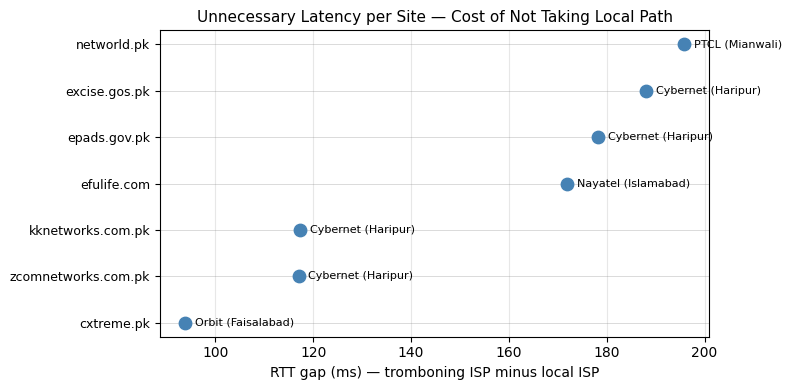

In [26]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.scatter(df_gap['gap_ms'], range(len(df_gap)), 
           color='steelblue', s=80, zorder=3)

for i, (_, row) in enumerate(df_gap.iterrows()):
    ax.text(row['gap_ms'] + 2, i, row['trombone_isp'], va='center', fontsize=8)
    ax.axhline(i, color='gray', linewidth=0.4, alpha=0.5)

ax.set_yticks(range(len(df_gap)))
ax.set_yticklabels(df_gap['site'], fontsize=9)
ax.set_xlabel('RTT gap (ms) — tromboning ISP minus local ISP', fontsize=10)
ax.set_title('Unnecessary Latency per Site — Cost of Not Taking Local Path', fontsize=11)
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('figures/fig_gap_dotplot.pdf', bbox_inches='tight')
plt.show()

**Latency Gap**

A dot plot showing the same seven sites ranked by the size of the RTT gap between the best and worst performing ISP. Each dot represents one site and is labelled with the tromboning ISP. Sites further to the right have a larger penalty for ISPs that don't take the local path.

## Section 6: Anomalies

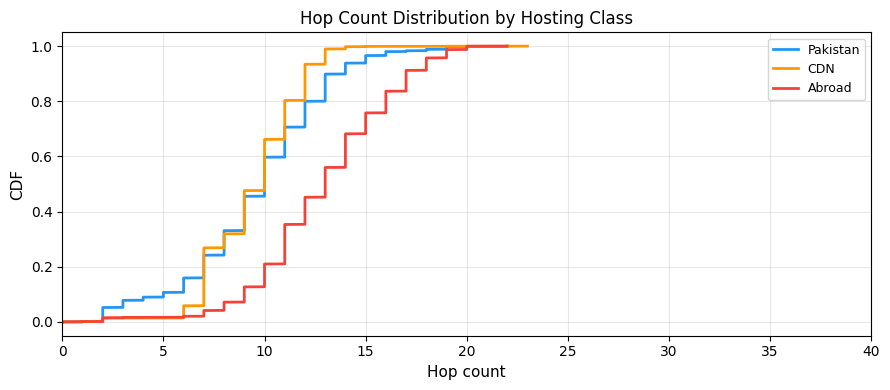

In [27]:
# ── Hop Count Distribution by Hosting Class ──────────────────────────────────
trace_hops['cls_label'] = trace_hops['cls'].map(
    {'Pakistan': 'PK-hosted', 'CDN': 'CDN', 'Abroad': 'Abroad'})

fig, ax = plt.subplots(figsize=(9, 4))
for cls, color in [('Pakistan','#2196F3'), ('CDN','#FF9800'), ('Abroad','#F44336')]:
    subset = trace_hops[trace_hops['cls'] == cls]['hop_count'].dropna()
    sorted_vals = np.sort(subset)
    cdf = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)
    ax.plot(sorted_vals, cdf, label=cls, color=color, linewidth=2)

ax.set_xlabel('Hop count', fontsize=11)
ax.set_ylabel('CDF', fontsize=11)
ax.set_title('Hop Count Distribution by Hosting Class', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 40)
plt.tight_layout()
plt.savefig('figures/fig_hop_count_cdf.pdf', bbox_inches='tight')
plt.show()

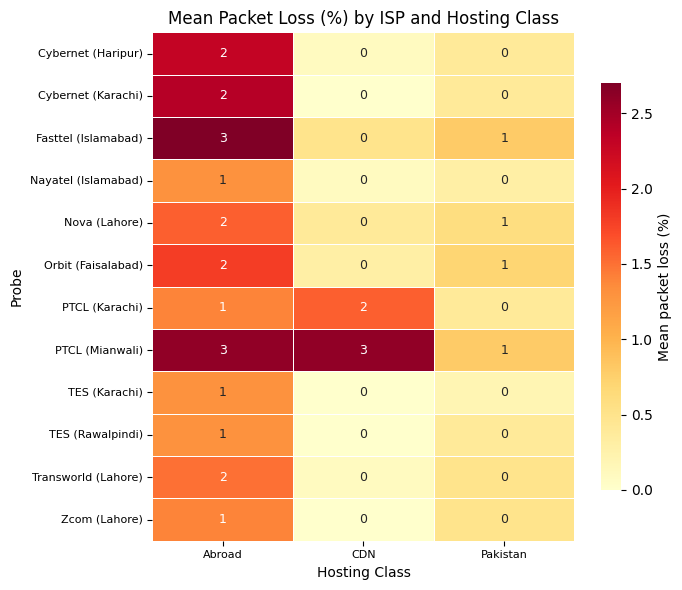

In [28]:
# ── Packet Loss Heatmap ───────────────────────────────────────────────────────
loss_pivot = (
    ping_clean
    .groupby(['probe_label', 'cls'])['loss']
    .mean()
    .unstack('cls')
    .round(3)
)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    loss_pivot * 100, ax=ax,
    cmap='YlOrRd',
    annot=True, fmt='.0f',
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Mean packet loss (%)', 'shrink': 0.8},
    annot_kws={'size': 9}
)
ax.set_title('Mean Packet Loss (%) by ISP and Hosting Class', fontsize=12)
ax.set_xlabel('Hosting Class')
ax.set_ylabel('Probe')
ax.tick_params(axis='both', rotation=0, labelsize=8)
plt.tight_layout()
plt.savefig('figures/fig_packet_loss.pdf', bbox_inches='tight')
plt.show()

Top 4 most variable probe-site pairs:
    probe_label           target    rtt_std
PTCL (Mianwali)      psca.gop.pk 178.899255
PTCL (Mianwali) nawaiwaqt.com.pk 178.171320
PTCL (Mianwali)       gbn.net.pk 177.439546
PTCL (Mianwali)   hostpro.com.pk 175.509737


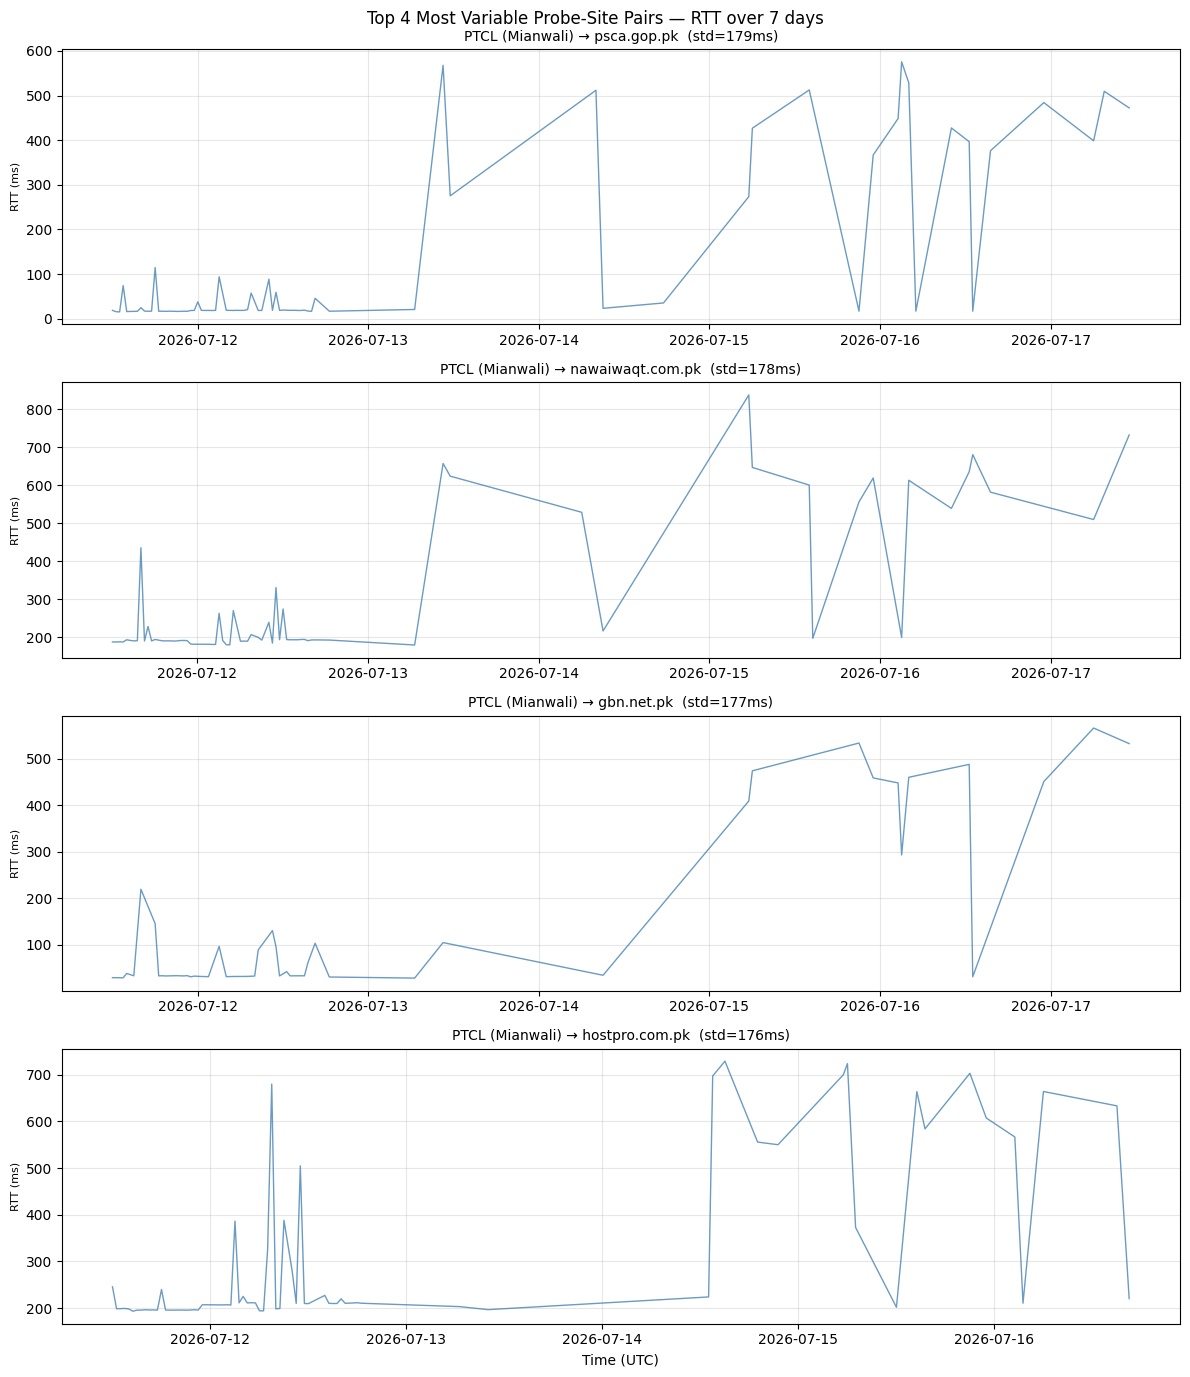

In [29]:
# ── Anomaly Detection ─────────────────────────────────────────────────────────
# Automatically find probe-site pairs with highest RTT variance over 7 days

variance = (
    ping_clean
    .groupby(['probe_label', 'target'])['rtt_min']
    .std()
    .reset_index()
    .rename(columns={'rtt_min': 'rtt_std'})
    .sort_values('rtt_std', ascending=False)
)

# exclude high loss sites
loss_check = ping_clean.groupby(['probe_label', 'target'])['loss'].mean()
high_loss  = loss_check[loss_check > 0.9].index
variance   = variance[~variance.set_index(['probe_label','target']).index.isin(high_loss)]

top_pairs = variance.head(4)
print("Top 4 most variable probe-site pairs:")
print(top_pairs.to_string(index=False))

fig, axes = plt.subplots(4, 1, figsize=(12, 14))
for ax, (_, row) in zip(axes, top_pairs.iterrows()):
    subset = ping_clean[
        (ping_clean['probe_label'] == row['probe_label']) &
        (ping_clean['target']      == row['target'])
    ].sort_values('ts_utc')

    ax.plot(subset['ts_utc'], subset['rtt_min'],
            linewidth=1.0, color='steelblue', alpha=0.8)
    ax.set_title(f"{row['probe_label']} → {row['target']}  (std={row['rtt_std']:.0f}ms)",
                 fontsize=10)
    ax.set_ylabel('RTT (ms)', fontsize=8)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (UTC)', fontsize=10)
fig.suptitle('Top 4 Most Variable Probe-Site Pairs — RTT over 7 days', fontsize=12)
plt.tight_layout()
plt.savefig('figures/fig_anomaly_detection.pdf', bbox_inches='tight')
plt.show()

**Anomaly Detection**

Note: PTCL (Mianwali) probe disconnected on 2026-07-17 and is excluded from anomaly 
detection since its high RTT variance reflects probe instability rather than genuine 
routing anomalies.

Top 4 most variable probe-site pairs:
   probe_label           target    rtt_std
PTCL (Karachi) logoofficial.com 131.851335
PTCL (Karachi)   urbanbeauty.pk 131.796555
PTCL (Karachi)     zarajahan.pk 112.873816
PTCL (Karachi)    motifz.com.pk 112.803160


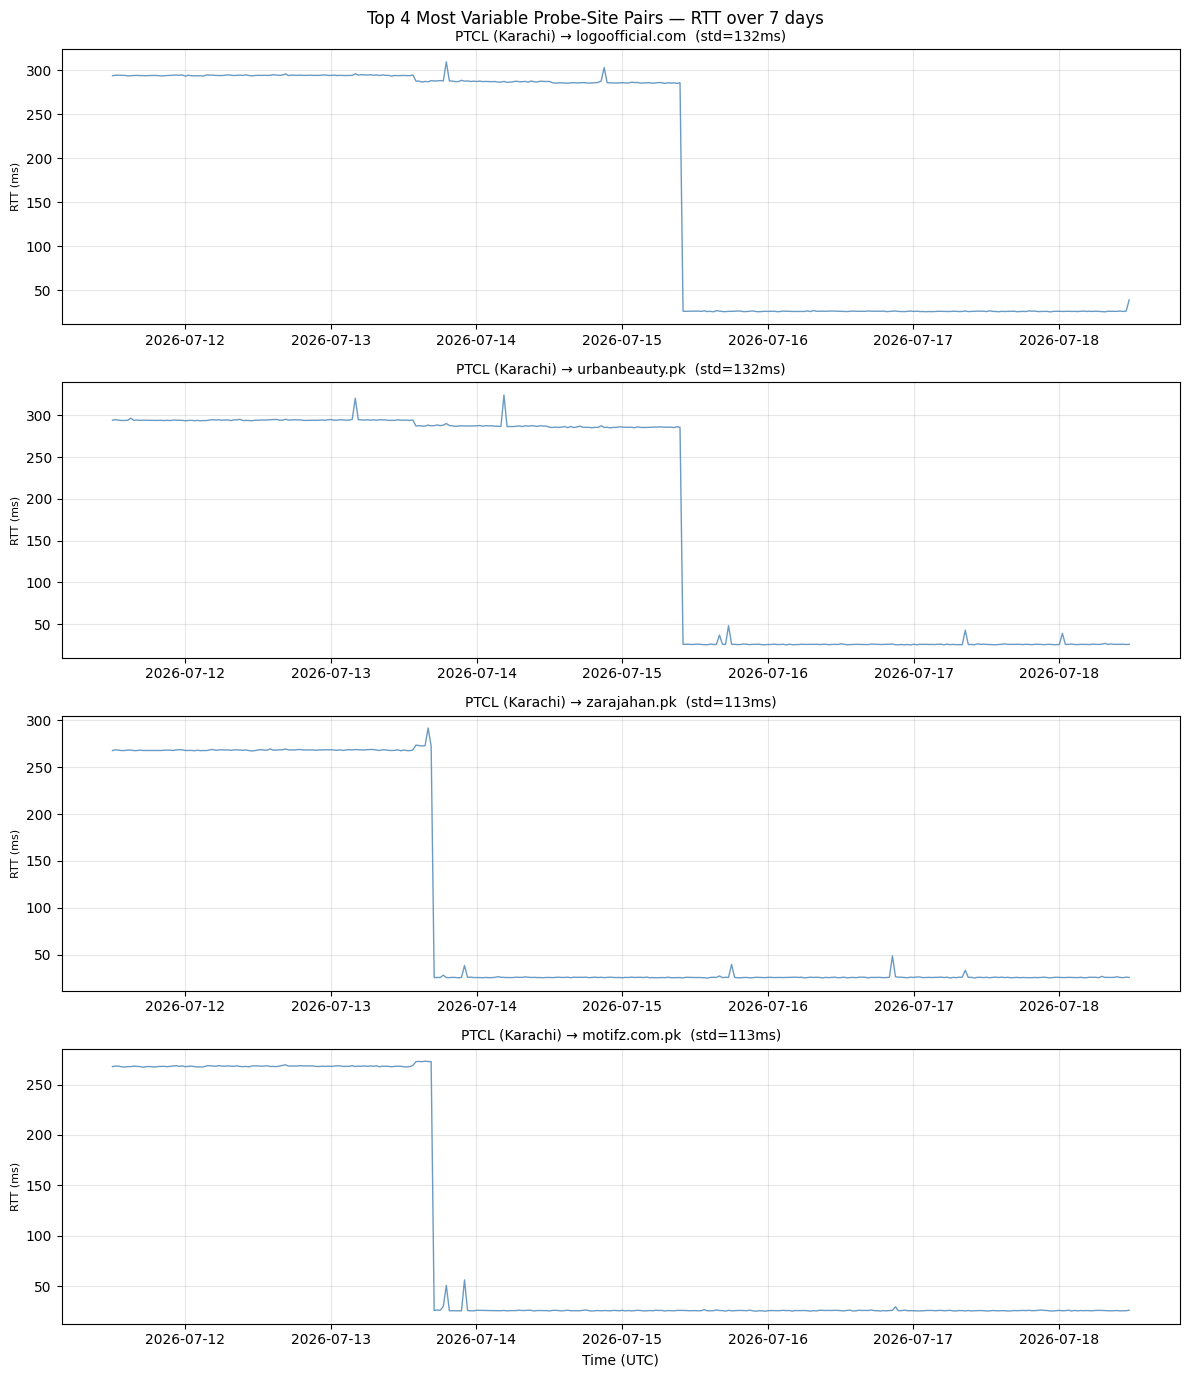

In [30]:
# ── Anomaly Detection ─────────────────────────────────────────────────────────
# Automatically find probe-site pairs with highest RTT variance over 7 days

variance = (
    ping_clean
    .groupby(['probe_label', 'target'])['rtt_min']
    .std()
    .reset_index()
    .rename(columns={'rtt_min': 'rtt_std'})
    .sort_values('rtt_std', ascending=False)
)

# exclude high loss sites
loss_check = ping_clean.groupby(['probe_label', 'target'])['loss'].mean()
high_loss  = loss_check[loss_check > 0.9].index
variance = variance[variance['probe_label'] != 'PTCL (Mianwali)']
top_pairs = variance.head(4)


print("Top 4 most variable probe-site pairs:")
print(top_pairs.to_string(index=False))

fig, axes = plt.subplots(4, 1, figsize=(12, 14))
for ax, (_, row) in zip(axes, top_pairs.iterrows()):
    subset = ping_clean[
        (ping_clean['probe_label'] == row['probe_label']) &
        (ping_clean['target']      == row['target'])
    ].sort_values('ts_utc')

    ax.plot(subset['ts_utc'], subset['rtt_min'],
            linewidth=1.0, color='steelblue', alpha=0.8)
    ax.set_title(f"{row['probe_label']} → {row['target']}  (std={row['rtt_std']:.0f}ms)",
                 fontsize=10)
    ax.set_ylabel('RTT (ms)', fontsize=8)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (UTC)', fontsize=10)
fig.suptitle('Top 4 Most Variable Probe-Site Pairs — RTT over 7 days', fontsize=12)
plt.tight_layout()
plt.savefig('figures/fig_anomaly_detection.pdf', bbox_inches='tight')
plt.show()

In [31]:
print(ping_clean[ping_clean['target'].isin(['urbanbeauty.pk', 'logoofficial.com', 
                                             'motifz.com.pk', 'zarajahan.pk'])
                ][['target','cls']].drop_duplicates())

                  target  cls
222961  logoofficial.com  CDN
249701     motifz.com.pk  CDN
387857    urbanbeauty.pk  CDN
423497      zarajahan.pk  CDN


PTCL Karachi shows the highest RTT variance to CDN-hosted sites across the 7-day window. All four most variable probe-site pairs involve PTCL Karachi reaching Pakistani e-commerce and fashion sites served via Cloudflare. This instability suggests PTCL's path to CDN content fluctuates significantly over time, in contrast to ISPs with stable direct CDN peering arrangements such as Nayatel which consistently achieves sub-5ms RTT to the same CDN.

## Section 7: CDN peering & latency ratio (RQ1) — from precomputed CSVs

The next three figures reuse already-computed per-pair CSVs (`cdn.csv`, `ratio_corrected.csv`) produced by `geo.py` rather than recomputing from `ping_clean`/`trace_clean`, since a CDN's anycast IP has no single serving location — see `METHODOLOGY.md §9` for why the per-ISP RTT treatment replaces geolocation for this class.

**CDN Access by ISP (RQ1)**

A 100%-stacked horizontal bar chart, one bar per ISP, built from `cdn.csv` (one row per probe × CDN-site pair, classified by measured min-RTT: local <15 ms, regional 15-50 ms, distant >50 ms — thresholds from Exp 1.2). Green = share of CDN sites that ISP reaches from a local PoP, amber = regional, red = distant; each bar is annotated with its % local and median RTT.

ISPs with more than one probe (Cybernet, Nayatel, PTCL, TES) contribute one row per (probe, site) pair rather than being collapsed to a single probe first, so their score is pooled across all of their measured vantage points — this matches the scoring already used in `geo.py cdn` / `METHODOLOGY.md §9.3`, which is why we read from `cdn.csv` rather than recompute per-ISP figures from scratch. This directly answers RQ1: for identical CDN content, how much of it is actually served from inside Pakistan depends heavily on which ISP the client is on.

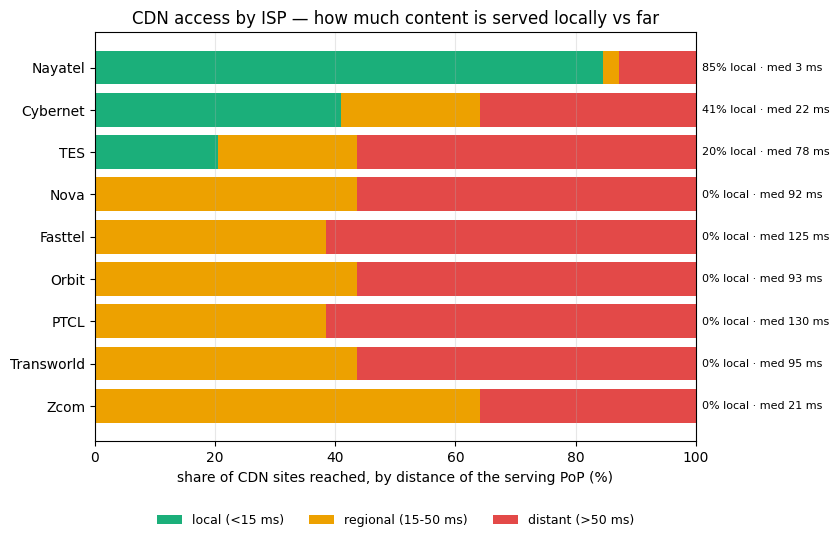

In [32]:
# ── CDN Access by ISP (RQ1) ───────────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt

ISP_DISPLAY = {
    'cybernet': 'Cybernet', 'fasttel': 'Fasttel', 'nayatel': 'Nayatel',
    'nova': 'Nova', 'orbit': 'Orbit', 'ptcl': 'PTCL', 'tes': 'TES',
    'transworld': 'Transworld', 'zcom': 'Zcom',
}

cdn = pd.read_csv('cdn.csv')

def pct(s, k):
    return round((s == k).mean() * 100, 1)

summ = cdn.groupby('isp').apply(lambda g: pd.Series({
    'n_pairs':      len(g),
    'median_rtt':   g['min_rtt_ms'].median(),
    'pct_local':    pct(g['pop_class'], 'local'),
    'pct_regional': pct(g['pop_class'], 'regional'),
    'pct_distant':  pct(g['pop_class'], 'distant'),
}), include_groups=False).reset_index()
summ['isp_label'] = summ['isp'].map(ISP_DISPLAY)
summ = summ.sort_values('pct_local', ascending=False)

GREEN, AMBER, RED = '#1baf7a', '#eda100', '#e34948'

fig, ax = plt.subplots(figsize=(8.5, 0.45 * len(summ) + 1.5))
labs = summ['isp_label'][::-1]
loc, reg, dis = summ['pct_local'][::-1], summ['pct_regional'][::-1], summ['pct_distant'][::-1]

ax.barh(labs, loc, color=GREEN, label='local (<15 ms)')
ax.barh(labs, reg, left=loc, color=AMBER, label='regional (15-50 ms)')
ax.barh(labs, dis, left=loc + reg, color=RED, label='distant (>50 ms)')

for i, (l, m) in enumerate(zip(loc, summ['median_rtt'][::-1])):
    ax.text(101, i, f'{l:.0f}% local · med {m:.0f} ms', va='center', fontsize=8)

ax.set_xlim(0, 100)
ax.set_xlabel('share of CDN sites reached, by distance of the serving PoP (%)')
ax.set_title('CDN access by ISP — how much content is served locally vs far')
ax.legend(frameon=False, ncol=3, fontsize=9, loc='upper center', bbox_to_anchor=(0.5, -0.15))
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

**CDN Reachability Heatmap**

A heatmap with ISPs as rows and CDN sites as columns, from `cdn.csv`. Each cell is colored by pop_class — green (local, <15 ms), amber (regional, 15-50 ms), red (distant, >50 ms).

Unlike the stacked bar above, a heatmap needs exactly one classification per (ISP, site) cell, so for the four ISPs with multiple probes each cell takes that ISP's **best** (minimum-RTT) PoP for that site — i.e. "does this ISP have *any* local path to this CDN," the existence-of-a-local-PoP reading from `METHODOLOGY.md §9.2`. Rows are ordered by overall CDN-locality score (best ISP at top) and columns by average difficulty (hardest sites on the right), so the pattern of green vs red columns separates "sites everyone reaches locally" from "sites nobody does" from the ISP-dependent middle ground that is the real RQ1 signal.

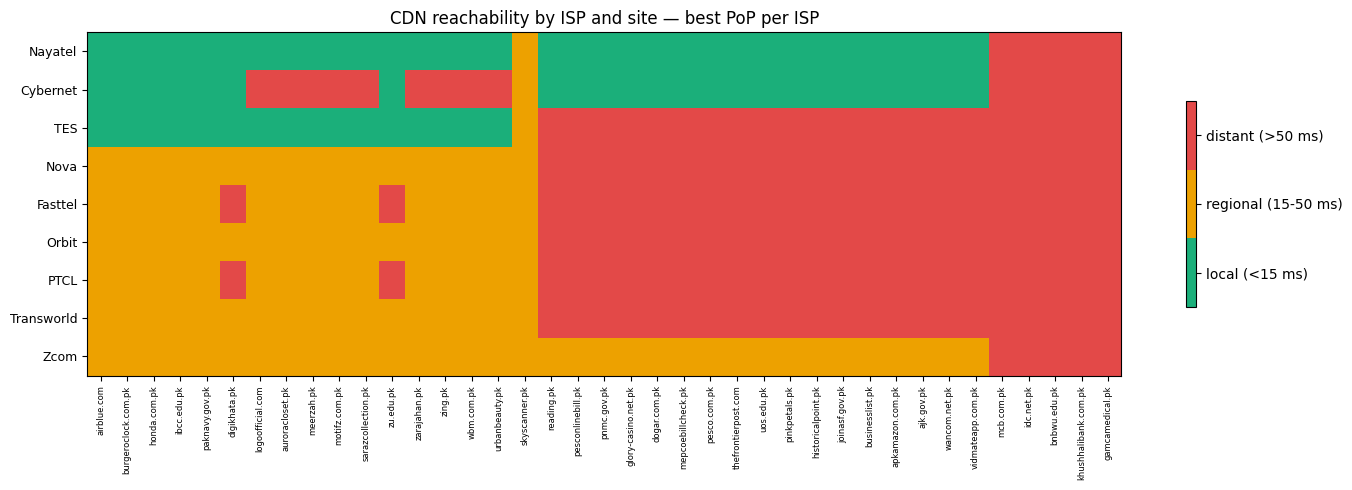

In [33]:
# ── CDN Reachability Heatmap ──────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

cdn = pd.read_csv('cdn.csv')

# collapse multi-probe ISPs to one row per (isp, site): that ISP's best (min RTT) PoP
cdn_best = (
    cdn.groupby(['isp', 'site'])['min_rtt_ms']
    .min()
    .reset_index()
)
cdn_best['pop_class'] = pd.cut(
    cdn_best['min_rtt_ms'], bins=[-0.01, 15, 50, np.inf],
    labels=['local', 'regional', 'distant']
)
class_num = {'local': 0, 'regional': 1, 'distant': 2}
cdn_best['class_num'] = cdn_best['pop_class'].map(class_num).astype(int)

pivot = cdn_best.pivot(index='isp', columns='site', values='class_num')
pivot.index = pivot.index.map(ISP_DISPLAY)

row_order = summ.sort_values('pct_local', ascending=False)['isp_label']
pivot = pivot.loc[row_order]
col_order = pivot.mean(axis=0).sort_values().index
pivot = pivot[col_order]

GREEN, AMBER, RED = '#1baf7a', '#eda100', '#e34948'
cmap = mcolors.ListedColormap([GREEN, AMBER, RED])

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(pivot.values, cmap=cmap, vmin=-0.5, vmax=2.5, aspect='auto')

ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=9)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=90, fontsize=6)
ax.set_title('CDN reachability by ISP and site — best PoP per ISP')

cbar = fig.colorbar(im, ticks=[0, 1, 2], shrink=0.6)
cbar.ax.set_yticklabels(['local (<15 ms)', 'regional (15-50 ms)', 'distant (>50 ms)'])

plt.tight_layout()
plt.show()

**Latency Ratio CDF — Pakistan vs Abroad vs CDN**

A CDF of latency ratio (measured RTT ÷ theoretical minimum, dimensionless) with one curve per site class, from `ratio_corrected.csv` (Pakistan, Abroad) and `cdn.csv` (CDN). 1.0× means a connection is already at its floor; the further right a curve sits, the more latency is being lost to routing rather than physics.

The two classes use different — but comparable — floor definitions (`METHODOLOGY.md §9.3b`): for Pakistan/Abroad the floor is the speed-of-light-in-fibre time over great-circle distance (`ratio` column), an unreachable physical minimum; for CDN there is no single server location, so the floor is the **best RTT any Pakistani probe actually achieves** to that site (`ratio_vs_best` column) — an attainable target, since any ISP could in principle peer its way to match the best-performing ISP. Only inter-city pairs (`intercity == True`) are used for PK/Abroad, since same-city pairs have a near-zero theoretical minimum that makes the ratio numerically unstable. Colors and axis follow the existing `geo.py cmd_correct` reference figure (`figures/ratio_cdf_all3.png`) for consistency with the rest of the analysis.

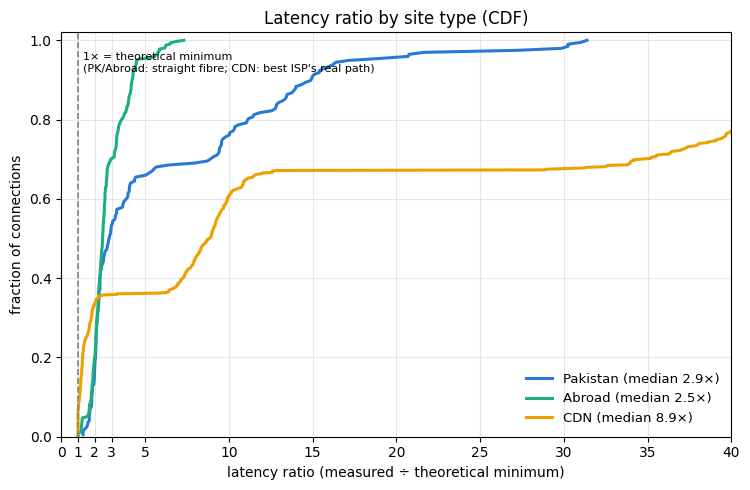

In [34]:
# ── Latency Ratio CDF — Pakistan vs Abroad vs CDN ─────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

rc  = pd.read_csv('ratio_corrected.csv')
cdn = pd.read_csv('cdn.csv')

ic = rc[rc['intercity']]  # exclude same-city pairs, theoretical minimum too close to zero

BLUE, GREEN, AMBER = '#2a78d6', '#1baf7a', '#eda100'
series = [
    ('Pakistan', ic[ic['cls'] == 'Pakistan']['ratio'], BLUE),
    ('Abroad',   ic[ic['cls'] == 'Abroad']['ratio'],   GREEN),
    ('CDN',      cdn['ratio_vs_best'],                  AMBER),
]

fig, ax = plt.subplots(figsize=(7.6, 5.0))
for name, vals, c in series:
    v = np.sort(vals.dropna().values)
    y = np.arange(1, len(v) + 1) / len(v)
    ax.plot(v, y, color=c, lw=2.2, label=f'{name} (median {np.median(v):.1f}×)')

ax.axvline(1, color='gray', lw=1.2, ls='--')
ax.text(1.3, 0.97,
        "1× = theoretical minimum\n(PK/Abroad: straight fibre; CDN: best ISP's real path)",
        fontsize=8, va='top')
ax.set_xlim(0, 40)
ax.set_ylim(0, 1.02)
ax.set_xticks([0, 1, 2, 3, 5, 10, 15, 20, 25, 30, 35, 40])
ax.set_xlabel('latency ratio (measured ÷ theoretical minimum)')
ax.set_ylabel('fraction of connections')
ax.set_title('Latency ratio by site type (CDF)')
ax.legend(frameon=False, fontsize=9.5, loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()